### Imports

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

%matplotlib inline 
mpl.rcParams['figure.dpi'] = 300

In [3]:
from sklearn.preprocessing import Normalizer

In [4]:
from chart_studio import plotly
import plotly.figure_factory as ff

In [5]:
pd.options.display.max_rows = 4000
pd.options.display.max_columns = 4000

In [6]:
DATA_VERSION = 'v5'

In [7]:
fig_dir = '../' + DATA_VERSION + '-fig/fig-courts/SCCS/'

In [8]:
gov_arch_csv = '../data/' + DATA_VERSION + '/communities_data_prepped.csv'

In [9]:
gov_df = pd.read_csv(gov_arch_csv)

In [10]:
# SCCS only
gov_df = gov_df.loc[gov_df['is_SCCS'] == 1]

In [11]:
gov_df.head()

,Name,Institutions,Mechanism,Notes,Time span,Geography,Size,Source,Metanotes,Heterogeneity,FC comments,expert check,Time span: Start,Time span: End,SCCS,is_SCCS,decision_making_mechanisms_include_representation,enforcement_mechanisms_include_paying_damages_compensation,decision_making_mechanisms_include_temporary_position_of_power_term_limits,enforcement_mechanisms_include_forced_labour,decision_making_mechanisms_include_remunerated_position,access_mechanisms_include_property_requirement,access_mechanisms_include_induction_rite_ceremony,access_mechanisms_include_gerontocracy,decision_making_mechanisms_include_majority_voting,enforcement_mechanisms_include_graduated_sanctions,decision_making_mechanisms_include_plurality_voting,enforcement_mechanisms_include_monitoring,decision_making_mechanisms_include_assembly_local,decision_making_mechanisms_include_petition,access_mechanisms_include_enfranchisement,access_mechanisms_include_age_boundaries,enforcement_mechanisms_include_exit,decision_making_mechanisms_include_secret_ballot,decision_making_mechanisms_include_coalition,access_mechanisms_include_screening_process,decision_making_mechanisms_include_checks_and_balances,decision_making_mechanisms_include_consensus,decision_making_mechanisms_include_balance_of_power,enforcement_mechanisms_include_self-help,decision_making_mechanisms_include_ratification_acclamation_only,enforcement_mechanisms_include_civil_disobedience,enforcement_mechanisms_include_criticism_mocking_joking,decision_making_mechanisms_include_bureaucracy,access_mechanisms_include_meritocracy,decision_making_mechanisms_include_consent,enforcement_mechanisms_include_appeal,enforcement_mechanisms_include_litigation,decision_making_mechanisms_include_quorum,enforcement_mechanisms_include_reputational_risk,decision_making_mechanisms_include_agenda_setting,enforcement_mechanisms_include_mediation,decision_making_mechanisms_include_magistrate_official,decision_making_mechanisms_include_confederacy,decision_making_mechanisms_include_delegation,access_mechanisms_include_matriarchy,decision_making_mechanisms_include_council_central_,decision_making_mechanisms_include_dual-sex_political_system,enforcement_mechanisms_include_judicial_review,enforcement_mechanisms_include_scrutiny_of_officials,decision_making_mechanisms_include_word_of_mouth,decision_making_mechanisms_include_consultation,decision_making_mechanisms_include_mandate,decision_making_mechanisms_include_vote_by_proxy,access_mechanisms_include_heredity,access_mechanisms_include_co-optation,enforcement_mechanisms_include_arbitration,access_mechanisms_include_payment_for_occupying_office,access_mechanisms_include_dreaming,enforcement_mechanisms_include_negotiation,decision_making_mechanisms_include_vote_by_show_of_hands,decision_making_mechanisms_include_frequent_and_or_regular_meetings,decision_making_mechanisms_include_assembly_central,decision_making_mechanisms_include_rule_of_law,access_mechanisms_include_matrilineality,access_mechanisms_include_patronage_for_office,decision_making_mechanisms_include_unanimity,enforcement_mechanisms_include_fines,decision_making_mechanisms_include_supermajority,access_mechanisms_include_blood_relations,decision_making_mechanisms_include_council_local,access_mechanisms_include_lottery_random_selection,decision_making_mechanisms_include_veto,decision_making_mechanisms_include_lobbying,enforcement_mechanisms_include_capital_punishment,decision_making_mechanisms_include_turnover_rotation,decision_making_mechanisms_include_autocratic_leader_chief_bound,enforcement_mechanisms_include_jury_judge,decision_making_mechanisms_include_gathering,enforcement_mechanisms_include_suspension_expulsion_ostracism_proscription,enforcement_mechanisms_include_corporal_punishment_violence_against_perpetrator,enforcement_mechanisms_include_destruction_of_property,enforcement_mechanisms_include_tribunal_court_,access_mechanisms_include_open_political_unit,decision_making_mechanisms_include_kingchief-as-figure

# Courts Analysis 

In [12]:
col_list = list(gov_df.columns.values)
col_list

['Name',
 'Institutions',
 'Mechanism',
 'Notes',
 'Time span',
 'Geography',
 'Size',
 'Source',
 'Metanotes',
 'Heterogeneity ',
 'FC comments',
 'expert check',
 'Time span: Start',
 'Time span: End',
 'SCCS',
 'is_SCCS',
 'decision_making_mechanisms_include_representation',
 'enforcement_mechanisms_include_paying_damages_compensation',
 'decision_making_mechanisms_include_temporary_position_of_power_term_limits',
 'enforcement_mechanisms_include_forced_labour',
 'decision_making_mechanisms_include_remunerated_position',
 'access_mechanisms_include_property_requirement',
 'access_mechanisms_include_induction_rite_ceremony',
 'access_mechanisms_include_gerontocracy',
 'decision_making_mechanisms_include_majority_voting',
 'enforcement_mechanisms_include_graduated_sanctions',
 'decision_making_mechanisms_include_plurality_voting',
 'enforcement_mechanisms_include_monitoring',
 'decision_making_mechanisms_include_assembly_local',
 'decision_making_mechanisms_include_petition',
 'access

In [13]:
court_col = ['enforcement_mechanisms_include_tribunal_court_']

In [14]:
courts = 'enforcement_mechanisms_include_tribunal_court_'

In [15]:
courts_df = gov_df[(gov_df['enforcement_mechanisms_include_tribunal_court_'] == 1)]

In [16]:
no_courts_df = gov_df[(gov_df['enforcement_mechanisms_include_tribunal_court_'] == 0)]

In [17]:
courts_df.head()

,Name,Institutions,Mechanism,Notes,Time span,Geography,Size,Source,Metanotes,Heterogeneity,FC comments,expert check,Time span: Start,Time span: End,SCCS,is_SCCS,decision_making_mechanisms_include_representation,enforcement_mechanisms_include_paying_damages_compensation,decision_making_mechanisms_include_temporary_position_of_power_term_limits,enforcement_mechanisms_include_forced_labour,decision_making_mechanisms_include_remunerated_position,access_mechanisms_include_property_requirement,access_mechanisms_include_induction_rite_ceremony,access_mechanisms_include_gerontocracy,decision_making_mechanisms_include_majority_voting,enforcement_mechanisms_include_graduated_sanctions,decision_making_mechanisms_include_plurality_voting,enforcement_mechanisms_include_monitoring,decision_making_mechanisms_include_assembly_local,decision_making_mechanisms_include_petition,access_mechanisms_include_enfranchisement,access_mechanisms_include_age_boundaries,enforcement_mechanisms_include_exit,decision_making_mechanisms_include_secret_ballot,decision_making_mechanisms_include_coalition,access_mechanisms_include_screening_process,decision_making_mechanisms_include_checks_and_balances,decision_making_mechanisms_include_consensus,decision_making_mechanisms_include_balance_of_power,enforcement_mechanisms_include_self-help,decision_making_mechanisms_include_ratification_acclamation_only,enforcement_mechanisms_include_civil_disobedience,enforcement_mechanisms_include_criticism_mocking_joking,decision_making_mechanisms_include_bureaucracy,access_mechanisms_include_meritocracy,decision_making_mechanisms_include_consent,enforcement_mechanisms_include_appeal,enforcement_mechanisms_include_litigation,decision_making_mechanisms_include_quorum,enforcement_mechanisms_include_reputational_risk,decision_making_mechanisms_include_agenda_setting,enforcement_mechanisms_include_mediation,decision_making_mechanisms_include_magistrate_official,decision_making_mechanisms_include_confederacy,decision_making_mechanisms_include_delegation,access_mechanisms_include_matriarchy,decision_making_mechanisms_include_council_central_,decision_making_mechanisms_include_dual-sex_political_system,enforcement_mechanisms_include_judicial_review,enforcement_mechanisms_include_scrutiny_of_officials,decision_making_mechanisms_include_word_of_mouth,decision_making_mechanisms_include_consultation,decision_making_mechanisms_include_mandate,decision_making_mechanisms_include_vote_by_proxy,access_mechanisms_include_heredity,access_mechanisms_include_co-optation,enforcement_mechanisms_include_arbitration,access_mechanisms_include_payment_for_occupying_office,access_mechanisms_include_dreaming,enforcement_mechanisms_include_negotiation,decision_making_mechanisms_include_vote_by_show_of_hands,decision_making_mechanisms_include_frequent_and_or_regular_meetings,decision_making_mechanisms_include_assembly_central,decision_making_mechanisms_include_rule_of_law,access_mechanisms_include_matrilineality,access_mechanisms_include_patronage_for_office,decision_making_mechanisms_include_unanimity,enforcement_mechanisms_include_fines,decision_making_mechanisms_include_supermajority,access_mechanisms_include_blood_relations,decision_making_mechanisms_include_council_local,access_mechanisms_include_lottery_random_selection,decision_making_mechanisms_include_veto,decision_making_mechanisms_include_lobbying,enforcement_mechanisms_include_capital_punishment,decision_making_mechanisms_include_turnover_rotation,decision_making_mechanisms_include_autocratic_leader_chief_bound,enforcement_mechanisms_include_jury_judge,decision_making_mechanisms_include_gathering,enforcement_mechanisms_include_suspension_expulsion_ostracism_proscription,enforcement_mechanisms_include_corporal_punishment_violence_against_perpetrator,enforcement_mechanisms_include_destruction_of_property,enforcement_mechanisms_include_tribunal_court_,access_mechanisms_include_open_political_unit,decision_making_mechanisms_include_kingchief-as-figure

In [18]:
no_courts_df.head()

,Name,Institutions,Mechanism,Notes,Time span,Geography,Size,Source,Metanotes,Heterogeneity,FC comments,expert check,Time span: Start,Time span: End,SCCS,is_SCCS,decision_making_mechanisms_include_representation,enforcement_mechanisms_include_paying_damages_compensation,decision_making_mechanisms_include_temporary_position_of_power_term_limits,enforcement_mechanisms_include_forced_labour,decision_making_mechanisms_include_remunerated_position,access_mechanisms_include_property_requirement,access_mechanisms_include_induction_rite_ceremony,access_mechanisms_include_gerontocracy,decision_making_mechanisms_include_majority_voting,enforcement_mechanisms_include_graduated_sanctions,decision_making_mechanisms_include_plurality_voting,enforcement_mechanisms_include_monitoring,decision_making_mechanisms_include_assembly_local,decision_making_mechanisms_include_petition,access_mechanisms_include_enfranchisement,access_mechanisms_include_age_boundaries,enforcement_mechanisms_include_exit,decision_making_mechanisms_include_secret_ballot,decision_making_mechanisms_include_coalition,access_mechanisms_include_screening_process,decision_making_mechanisms_include_checks_and_balances,decision_making_mechanisms_include_consensus,decision_making_mechanisms_include_balance_of_power,enforcement_mechanisms_include_self-help,decision_making_mechanisms_include_ratification_acclamation_only,enforcement_mechanisms_include_civil_disobedience,enforcement_mechanisms_include_criticism_mocking_joking,decision_making_mechanisms_include_bureaucracy,access_mechanisms_include_meritocracy,decision_making_mechanisms_include_consent,enforcement_mechanisms_include_appeal,enforcement_mechanisms_include_litigation,decision_making_mechanisms_include_quorum,enforcement_mechanisms_include_reputational_risk,decision_making_mechanisms_include_agenda_setting,enforcement_mechanisms_include_mediation,decision_making_mechanisms_include_magistrate_official,decision_making_mechanisms_include_confederacy,decision_making_mechanisms_include_delegation,access_mechanisms_include_matriarchy,decision_making_mechanisms_include_council_central_,decision_making_mechanisms_include_dual-sex_political_system,enforcement_mechanisms_include_judicial_review,enforcement_mechanisms_include_scrutiny_of_officials,decision_making_mechanisms_include_word_of_mouth,decision_making_mechanisms_include_consultation,decision_making_mechanisms_include_mandate,decision_making_mechanisms_include_vote_by_proxy,access_mechanisms_include_heredity,access_mechanisms_include_co-optation,enforcement_mechanisms_include_arbitration,access_mechanisms_include_payment_for_occupying_office,access_mechanisms_include_dreaming,enforcement_mechanisms_include_negotiation,decision_making_mechanisms_include_vote_by_show_of_hands,decision_making_mechanisms_include_frequent_and_or_regular_meetings,decision_making_mechanisms_include_assembly_central,decision_making_mechanisms_include_rule_of_law,access_mechanisms_include_matrilineality,access_mechanisms_include_patronage_for_office,decision_making_mechanisms_include_unanimity,enforcement_mechanisms_include_fines,decision_making_mechanisms_include_supermajority,access_mechanisms_include_blood_relations,decision_making_mechanisms_include_council_local,access_mechanisms_include_lottery_random_selection,decision_making_mechanisms_include_veto,decision_making_mechanisms_include_lobbying,enforcement_mechanisms_include_capital_punishment,decision_making_mechanisms_include_turnover_rotation,decision_making_mechanisms_include_autocratic_leader_chief_bound,enforcement_mechanisms_include_jury_judge,decision_making_mechanisms_include_gathering,enforcement_mechanisms_include_suspension_expulsion_ostracism_proscription,enforcement_mechanisms_include_corporal_punishment_violence_against_perpetrator,enforcement_mechanisms_include_destruction_of_property,enforcement_mechanisms_include_tribunal_court_,access_mechanisms_include_open_political_unit,decision_making_mechanisms_include_kingchief-as-figure

In [19]:
courts_df.describe()

,Time span: Start,Time span: End,is_SCCS,decision_making_mechanisms_include_representation,enforcement_mechanisms_include_paying_damages_compensation,decision_making_mechanisms_include_temporary_position_of_power_term_limits,enforcement_mechanisms_include_forced_labour,decision_making_mechanisms_include_remunerated_position,access_mechanisms_include_property_requirement,access_mechanisms_include_induction_rite_ceremony,access_mechanisms_include_gerontocracy,decision_making_mechanisms_include_majority_voting,enforcement_mechanisms_include_graduated_sanctions,decision_making_mechanisms_include_plurality_voting,enforcement_mechanisms_include_monitoring,decision_making_mechanisms_include_assembly_local,decision_making_mechanisms_include_petition,access_mechanisms_include_enfranchisement,access_mechanisms_include_age_boundaries,enforcement_mechanisms_include_exit,decision_making_mechanisms_include_secret_ballot,decision_making_mechanisms_include_coalition,access_mechanisms_include_screening_process,decision_making_mechanisms_include_checks_and_balances,decision_making_mechanisms_include_consensus,decision_making_mechanisms_include_balance_of_power,enforcement_mechanisms_include_self-help,decision_making_mechanisms_include_ratification_acclamation_only,enforcement_mechanisms_include_civil_disobedience,enforcement_mechanisms_include_criticism_mocking_joking,decision_making_mechanisms_include_bureaucracy,access_mechanisms_include_meritocracy,decision_making_mechanisms_include_consent,enforcement_mechanisms_include_appeal,enforcement_mechanisms_include_litigation,decision_making_mechanisms_include_quorum,enforcement_mechanisms_include_reputational_risk,decision_making_mechanisms_include_agenda_setting,enforcement_mechanisms_include_mediation,decision_making_mechanisms_include_magistrate_official,decision_making_mechanisms_include_confederacy,decision_making_mechanisms_include_delegation,access_mechanisms_include_matriarchy,decision_making_mechanisms_include_council_central_,decision_making_mechanisms_include_dual-sex_political_system,enforcement_mechanisms_include_judicial_review,enforcement_mechanisms_include_scrutiny_of_officials,decision_making_mechanisms_include_word_of_mouth,decision_making_mechanisms_include_consultation,decision_making_mechanisms_include_mandate,decision_making_mechanisms_include_vote_by_proxy,access_mechanisms_include_heredity,access_mechanisms_include_co-optation,enforcement_mechanisms_include_arbitration,access_mechanisms_include_payment_for_occupying_office,access_mechanisms_include_dreaming,enforcement_mechanisms_include_negotiation,decision_making_mechanisms_include_vote_by_show_of_hands,decision_making_mechanisms_include_frequent_and_or_regular_meetings,decision_making_mechanisms_include_assembly_central,decision_making_mechanisms_include_rule_of_law,access_mechanisms_include_matrilineality,access_mechanisms_include_patronage_for_office,decision_making_mechanisms_include_unanimity,enforcement_mechanisms_include_fines,decision_making_mechanisms_include_supermajority,access_mechanisms_include_blood_relations,decision_making_mechanisms_include_council_local,access_mechanisms_include_lottery_random_selection,decision_making_mechanisms_include_veto,decision_making_mechanisms_include_lobbying,enforcement_mechanisms_include_capital_punishment,decision_making_mechanisms_include_turnover_rotation,decision_making_mechanisms_include_autocratic_leader_chief_bound,enforcement_mechanisms_include_jury_judge,decision_making_mechanisms_include_gathering,enforcement_mechanisms_include_suspension_expulsion_ostracism_proscription,enforcement_mechanisms_include_corporal_punishment_violence_against_perpetrator,enforcement_mechanisms_include_destruction_of_property,enforcement_mechanisms_include_tribunal_court_,access_mechanisms_include_open_political_unit,decision_making_mechanisms_include_kingchief-as-figurehead,access_mechanisms_include_popularity_,enforcement_mechanisms_include_seizing_of_property,access_mechanisms_include_

In [20]:
no_courts_df.describe()

,Time span: Start,Time span: End,is_SCCS,decision_making_mechanisms_include_representation,enforcement_mechanisms_include_paying_damages_compensation,decision_making_mechanisms_include_temporary_position_of_power_term_limits,enforcement_mechanisms_include_forced_labour,decision_making_mechanisms_include_remunerated_position,access_mechanisms_include_property_requirement,access_mechanisms_include_induction_rite_ceremony,access_mechanisms_include_gerontocracy,decision_making_mechanisms_include_majority_voting,enforcement_mechanisms_include_graduated_sanctions,decision_making_mechanisms_include_plurality_voting,enforcement_mechanisms_include_monitoring,decision_making_mechanisms_include_assembly_local,decision_making_mechanisms_include_petition,access_mechanisms_include_enfranchisement,access_mechanisms_include_age_boundaries,enforcement_mechanisms_include_exit,decision_making_mechanisms_include_secret_ballot,decision_making_mechanisms_include_coalition,access_mechanisms_include_screening_process,decision_making_mechanisms_include_checks_and_balances,decision_making_mechanisms_include_consensus,decision_making_mechanisms_include_balance_of_power,enforcement_mechanisms_include_self-help,decision_making_mechanisms_include_ratification_acclamation_only,enforcement_mechanisms_include_civil_disobedience,enforcement_mechanisms_include_criticism_mocking_joking,decision_making_mechanisms_include_bureaucracy,access_mechanisms_include_meritocracy,decision_making_mechanisms_include_consent,enforcement_mechanisms_include_appeal,enforcement_mechanisms_include_litigation,decision_making_mechanisms_include_quorum,enforcement_mechanisms_include_reputational_risk,decision_making_mechanisms_include_agenda_setting,enforcement_mechanisms_include_mediation,decision_making_mechanisms_include_magistrate_official,decision_making_mechanisms_include_confederacy,decision_making_mechanisms_include_delegation,access_mechanisms_include_matriarchy,decision_making_mechanisms_include_council_central_,decision_making_mechanisms_include_dual-sex_political_system,enforcement_mechanisms_include_judicial_review,enforcement_mechanisms_include_scrutiny_of_officials,decision_making_mechanisms_include_word_of_mouth,decision_making_mechanisms_include_consultation,decision_making_mechanisms_include_mandate,decision_making_mechanisms_include_vote_by_proxy,access_mechanisms_include_heredity,access_mechanisms_include_co-optation,enforcement_mechanisms_include_arbitration,access_mechanisms_include_payment_for_occupying_office,access_mechanisms_include_dreaming,enforcement_mechanisms_include_negotiation,decision_making_mechanisms_include_vote_by_show_of_hands,decision_making_mechanisms_include_frequent_and_or_regular_meetings,decision_making_mechanisms_include_assembly_central,decision_making_mechanisms_include_rule_of_law,access_mechanisms_include_matrilineality,access_mechanisms_include_patronage_for_office,decision_making_mechanisms_include_unanimity,enforcement_mechanisms_include_fines,decision_making_mechanisms_include_supermajority,access_mechanisms_include_blood_relations,decision_making_mechanisms_include_council_local,access_mechanisms_include_lottery_random_selection,decision_making_mechanisms_include_veto,decision_making_mechanisms_include_lobbying,enforcement_mechanisms_include_capital_punishment,decision_making_mechanisms_include_turnover_rotation,decision_making_mechanisms_include_autocratic_leader_chief_bound,enforcement_mechanisms_include_jury_judge,decision_making_mechanisms_include_gathering,enforcement_mechanisms_include_suspension_expulsion_ostracism_proscription,enforcement_mechanisms_include_corporal_punishment_violence_against_perpetrator,enforcement_mechanisms_include_destruction_of_property,enforcement_mechanisms_include_tribunal_court_,access_mechanisms_include_open_political_unit,decision_making_mechanisms_include_kingchief-as-figurehead,access_mechanisms_include_popularity_,enforcement_mechanisms_include_seizing_of_property,access_mechanisms_include_

In [21]:
gov_df[court_col].value_counts()

enforcement_mechanisms_include_tribunal_court_
0                                                 24
1                                                 10
Name: count, dtype: int64

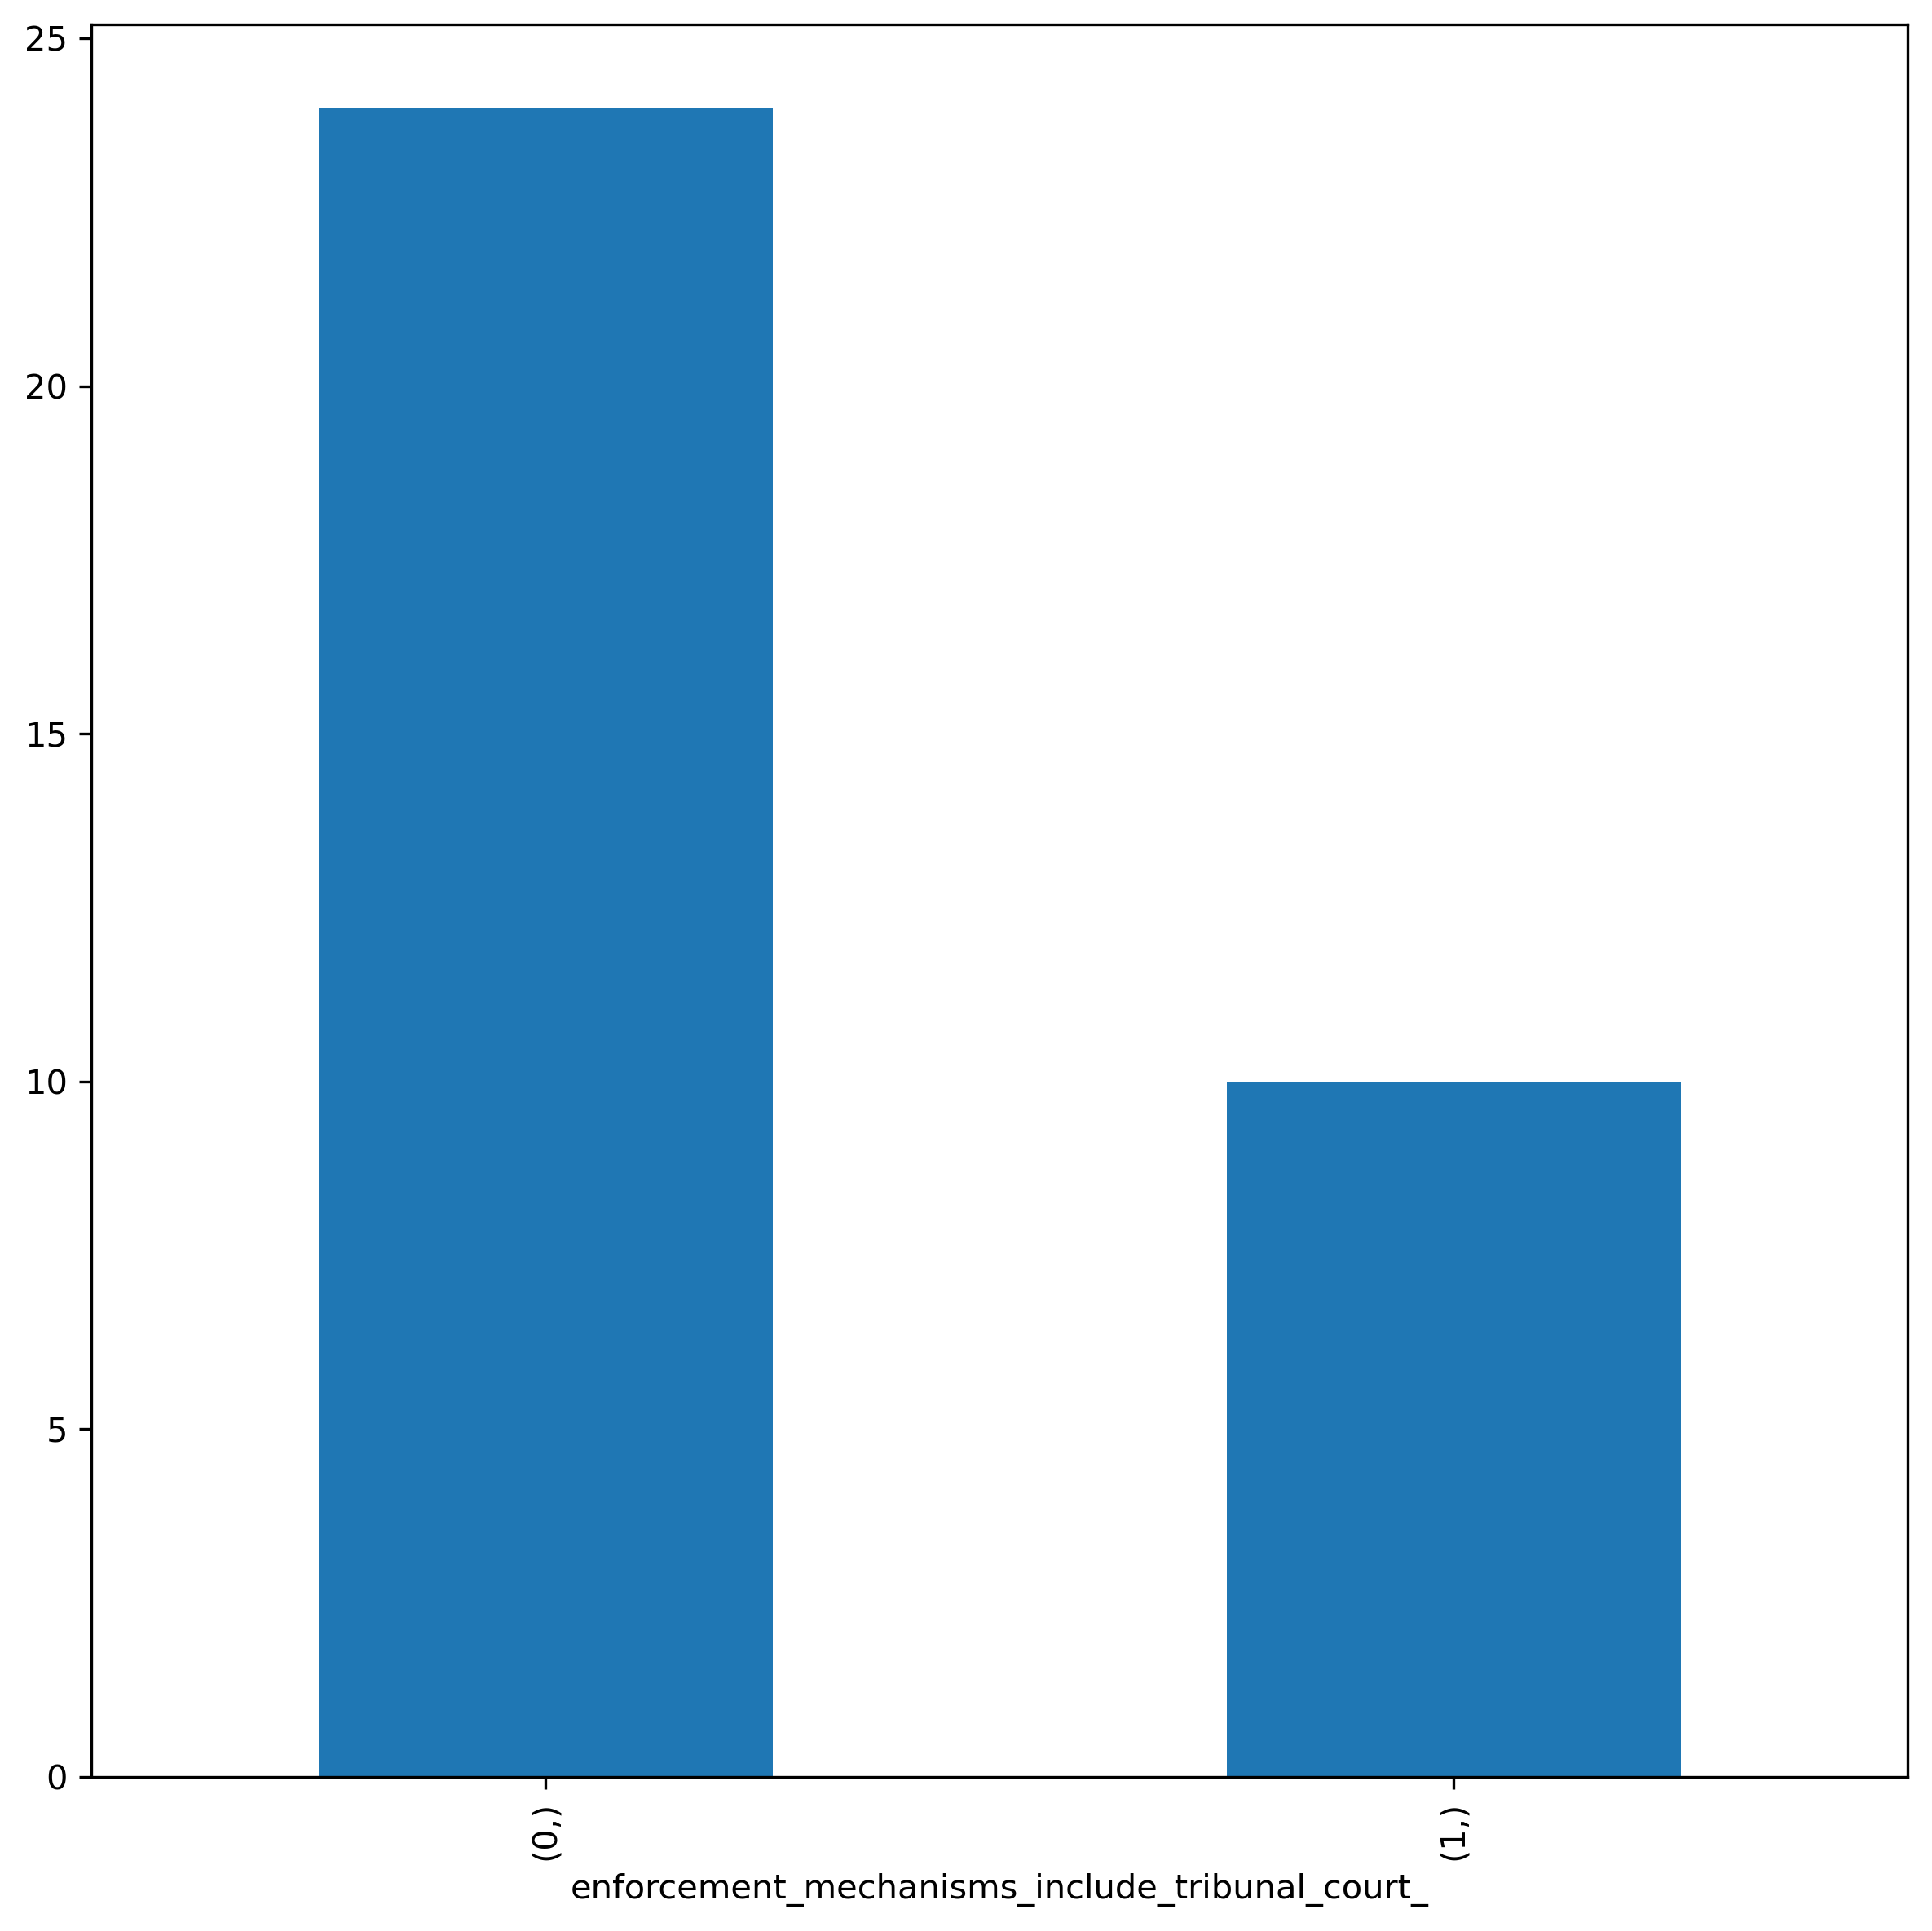

In [22]:
plt.figure(figsize=(8,8))

gov_df[court_col].value_counts().plot(kind='bar')

plt.tight_layout()
plt.savefig(fig_dir + 'histogram.png')
plt.show()

## Correlations

In [23]:
data_plot = gov_df.select_dtypes(include=[np.number]).dropna()

In [24]:
data_plot.describe()

,Time span: Start,Time span: End,is_SCCS,decision_making_mechanisms_include_representation,enforcement_mechanisms_include_paying_damages_compensation,decision_making_mechanisms_include_temporary_position_of_power_term_limits,enforcement_mechanisms_include_forced_labour,decision_making_mechanisms_include_remunerated_position,access_mechanisms_include_property_requirement,access_mechanisms_include_induction_rite_ceremony,access_mechanisms_include_gerontocracy,decision_making_mechanisms_include_majority_voting,enforcement_mechanisms_include_graduated_sanctions,decision_making_mechanisms_include_plurality_voting,enforcement_mechanisms_include_monitoring,decision_making_mechanisms_include_assembly_local,decision_making_mechanisms_include_petition,access_mechanisms_include_enfranchisement,access_mechanisms_include_age_boundaries,enforcement_mechanisms_include_exit,decision_making_mechanisms_include_secret_ballot,decision_making_mechanisms_include_coalition,access_mechanisms_include_screening_process,decision_making_mechanisms_include_checks_and_balances,decision_making_mechanisms_include_consensus,decision_making_mechanisms_include_balance_of_power,enforcement_mechanisms_include_self-help,decision_making_mechanisms_include_ratification_acclamation_only,enforcement_mechanisms_include_civil_disobedience,enforcement_mechanisms_include_criticism_mocking_joking,decision_making_mechanisms_include_bureaucracy,access_mechanisms_include_meritocracy,decision_making_mechanisms_include_consent,enforcement_mechanisms_include_appeal,enforcement_mechanisms_include_litigation,decision_making_mechanisms_include_quorum,enforcement_mechanisms_include_reputational_risk,decision_making_mechanisms_include_agenda_setting,enforcement_mechanisms_include_mediation,decision_making_mechanisms_include_magistrate_official,decision_making_mechanisms_include_confederacy,decision_making_mechanisms_include_delegation,access_mechanisms_include_matriarchy,decision_making_mechanisms_include_council_central_,decision_making_mechanisms_include_dual-sex_political_system,enforcement_mechanisms_include_judicial_review,enforcement_mechanisms_include_scrutiny_of_officials,decision_making_mechanisms_include_word_of_mouth,decision_making_mechanisms_include_consultation,decision_making_mechanisms_include_mandate,decision_making_mechanisms_include_vote_by_proxy,access_mechanisms_include_heredity,access_mechanisms_include_co-optation,enforcement_mechanisms_include_arbitration,access_mechanisms_include_payment_for_occupying_office,access_mechanisms_include_dreaming,enforcement_mechanisms_include_negotiation,decision_making_mechanisms_include_vote_by_show_of_hands,decision_making_mechanisms_include_frequent_and_or_regular_meetings,decision_making_mechanisms_include_assembly_central,decision_making_mechanisms_include_rule_of_law,access_mechanisms_include_matrilineality,access_mechanisms_include_patronage_for_office,decision_making_mechanisms_include_unanimity,enforcement_mechanisms_include_fines,decision_making_mechanisms_include_supermajority,access_mechanisms_include_blood_relations,decision_making_mechanisms_include_council_local,access_mechanisms_include_lottery_random_selection,decision_making_mechanisms_include_veto,decision_making_mechanisms_include_lobbying,enforcement_mechanisms_include_capital_punishment,decision_making_mechanisms_include_turnover_rotation,decision_making_mechanisms_include_autocratic_leader_chief_bound,enforcement_mechanisms_include_jury_judge,decision_making_mechanisms_include_gathering,enforcement_mechanisms_include_suspension_expulsion_ostracism_proscription,enforcement_mechanisms_include_corporal_punishment_violence_against_perpetrator,enforcement_mechanisms_include_destruction_of_property,enforcement_mechanisms_include_tribunal_court_,access_mechanisms_include_open_political_unit,decision_making_mechanisms_include_kingchief-as-figurehead,access_mechanisms_include_popularity_,enforcement_mechanisms_include_seizing_of_property,access_mechanisms_include_

In [25]:
normalized = Normalizer().fit_transform(data_plot)

norm_df = pd.DataFrame(normalized)
norm_df.columns = data_plot.columns
norm_corr = norm_df.corr()

norm_corr.head()

,Time span: Start,Time span: End,is_SCCS,decision_making_mechanisms_include_representation,enforcement_mechanisms_include_paying_damages_compensation,decision_making_mechanisms_include_temporary_position_of_power_term_limits,enforcement_mechanisms_include_forced_labour,decision_making_mechanisms_include_remunerated_position,access_mechanisms_include_property_requirement,access_mechanisms_include_induction_rite_ceremony,access_mechanisms_include_gerontocracy,decision_making_mechanisms_include_majority_voting,enforcement_mechanisms_include_graduated_sanctions,decision_making_mechanisms_include_plurality_voting,enforcement_mechanisms_include_monitoring,decision_making_mechanisms_include_assembly_local,decision_making_mechanisms_include_petition,access_mechanisms_include_enfranchisement,access_mechanisms_include_age_boundaries,enforcement_mechanisms_include_exit,decision_making_mechanisms_include_secret_ballot,decision_making_mechanisms_include_coalition,access_mechanisms_include_screening_process,decision_making_mechanisms_include_checks_and_balances,decision_making_mechanisms_include_consensus,decision_making_mechanisms_include_balance_of_power,enforcement_mechanisms_include_self-help,decision_making_mechanisms_include_ratification_acclamation_only,enforcement_mechanisms_include_civil_disobedience,enforcement_mechanisms_include_criticism_mocking_joking,decision_making_mechanisms_include_bureaucracy,access_mechanisms_include_meritocracy,decision_making_mechanisms_include_consent,enforcement_mechanisms_include_appeal,enforcement_mechanisms_include_litigation,decision_making_mechanisms_include_quorum,enforcement_mechanisms_include_reputational_risk,decision_making_mechanisms_include_agenda_setting,enforcement_mechanisms_include_mediation,decision_making_mechanisms_include_magistrate_official,decision_making_mechanisms_include_confederacy,decision_making_mechanisms_include_delegation,access_mechanisms_include_matriarchy,decision_making_mechanisms_include_council_central_,decision_making_mechanisms_include_dual-sex_political_system,enforcement_mechanisms_include_judicial_review,enforcement_mechanisms_include_scrutiny_of_officials,decision_making_mechanisms_include_word_of_mouth,decision_making_mechanisms_include_consultation,decision_making_mechanisms_include_mandate,decision_making_mechanisms_include_vote_by_proxy,access_mechanisms_include_heredity,access_mechanisms_include_co-optation,enforcement_mechanisms_include_arbitration,access_mechanisms_include_payment_for_occupying_office,access_mechanisms_include_dreaming,enforcement_mechanisms_include_negotiation,decision_making_mechanisms_include_vote_by_show_of_hands,decision_making_mechanisms_include_frequent_and_or_regular_meetings,decision_making_mechanisms_include_assembly_central,decision_making_mechanisms_include_rule_of_law,access_mechanisms_include_matrilineality,access_mechanisms_include_patronage_for_office,decision_making_mechanisms_include_unanimity,enforcement_mechanisms_include_fines,decision_making_mechanisms_include_supermajority,access_mechanisms_include_blood_relations,decision_making_mechanisms_include_council_local,access_mechanisms_include_lottery_random_selection,decision_making_mechanisms_include_veto,decision_making_mechanisms_include_lobbying,enforcement_mechanisms_include_capital_punishment,decision_making_mechanisms_include_turnover_rotation,decision_making_mechanisms_include_autocratic_leader_chief_bound,enforcement_mechanisms_include_jury_judge,decision_making_mechanisms_include_gathering,enforcement_mechanisms_include_suspension_expulsion_ostracism_proscription,enforcement_mechanisms_include_corporal_punishment_violence_against_perpetrator,enforcement_mechanisms_include_destruction_of_property,enforcement_mechanisms_include_tribunal_court_,access_mechanisms_include_open_political_unit,decision_making_mechanisms_include_kingchief-as-figurehead,access_mechanisms_include_popularity_,enforcement_mechanisms_include_seizing_of_property,access_mechanisms_include_

In [26]:
courts_corr = norm_corr[court_col]

In [27]:
courts_corr

,enforcement_mechanisms_include_tribunal_court_
Time span: Start,0.103388
Time span: End,0.188708
is_SCCS,-0.128267
decision_making_mechanisms_include_representation,0.292995
enforcement_mechanisms_include_paying_damages_compensation,NaN
decision_making_mechanisms_include_temporary_position_of_power_term_limits,-0.021999
enforcement_mechanisms_include_forced_labour,-0.111504
decision_making_mechanisms_include_remunerated_position,-0.111504
access_mechanisms_include_property_requirement,-0.111504
access_mechanisms_include_induction_rite_ceremony,-0.040855


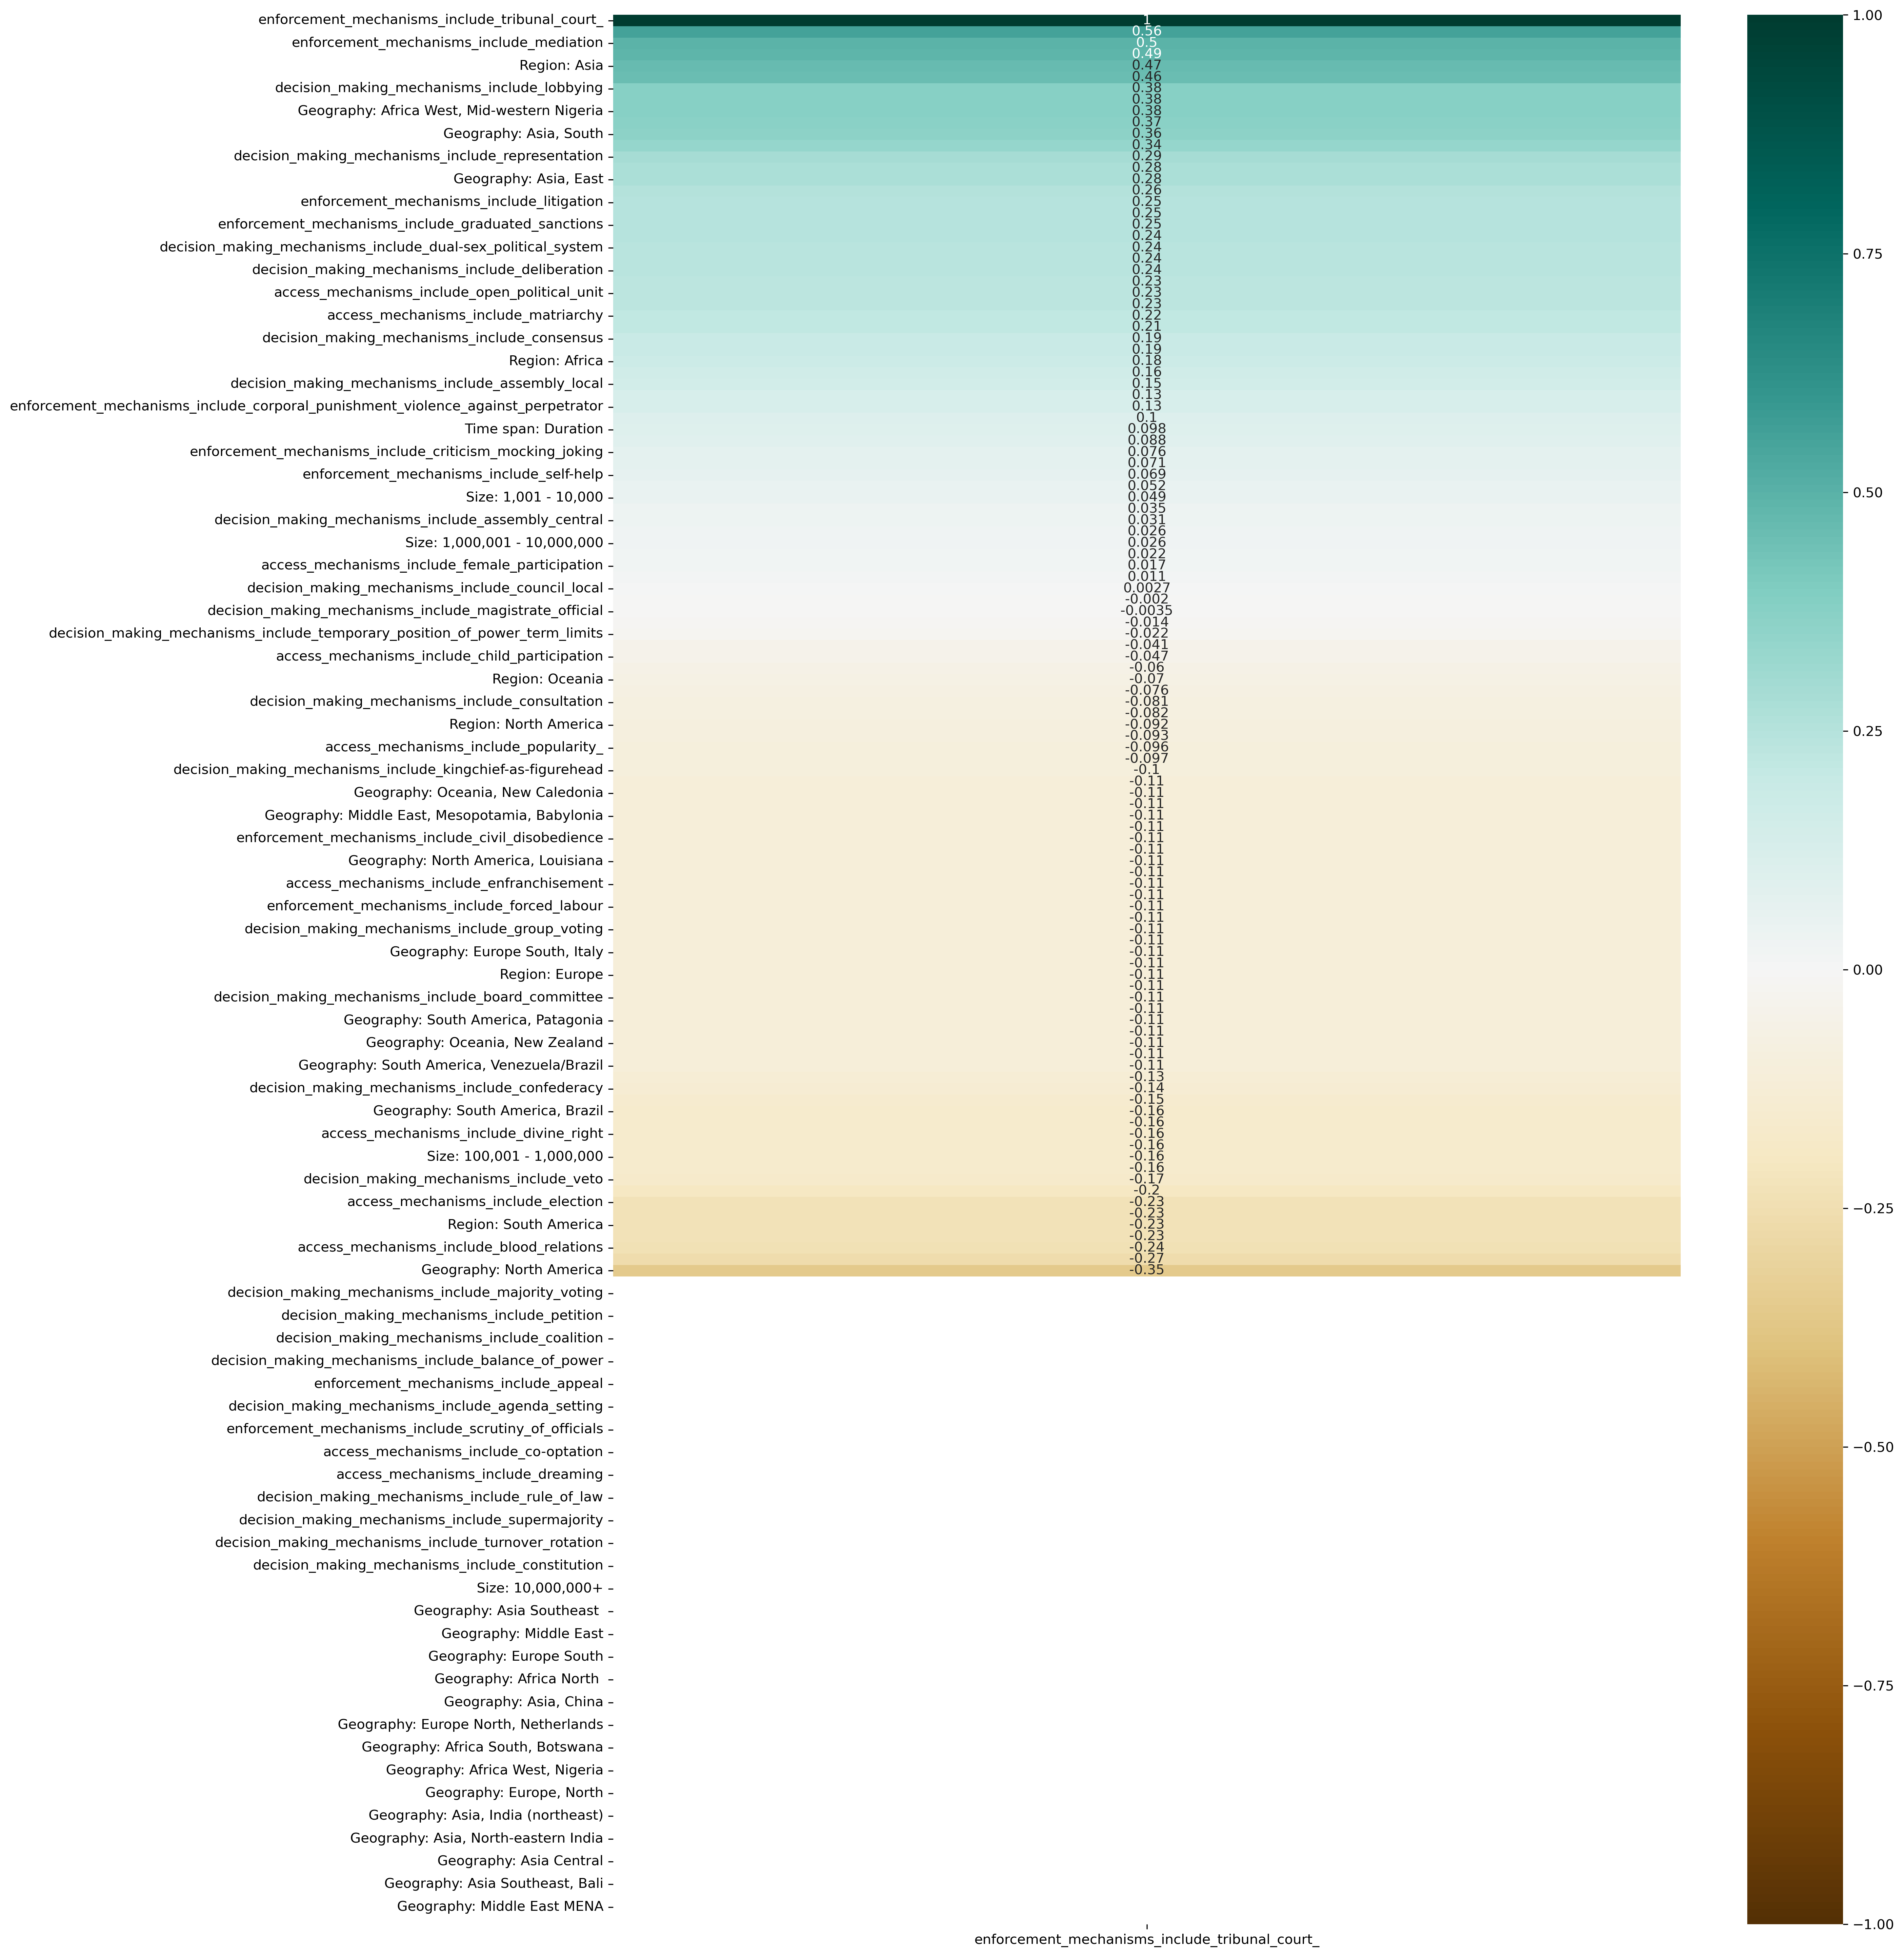

In [28]:
plt.figure(figsize=(20,20))
sns.heatmap(
    courts_corr.sort_values(by='enforcement_mechanisms_include_tribunal_court_', ascending=False), 
    annot=True,
    cmap='BrBG',
    vmin=-1,
    vmax=1
)

plt.tight_layout()
plt.savefig(fig_dir + 'courts_corr.png')
plt.show()

## Courts Analysis: Mechanisms

### Access

In [29]:
access_courts_corr = courts_corr[courts_corr.index.str.startswith('access')]

In [30]:
access_courts_corr

,enforcement_mechanisms_include_tribunal_court_
access_mechanisms_include_property_requirement,-0.111504
access_mechanisms_include_induction_rite_ceremony,-0.040855
access_mechanisms_include_gerontocracy,0.156339
access_mechanisms_include_enfranchisement,-0.111504
access_mechanisms_include_age_boundaries,-0.097216
access_mechanisms_include_screening_process,NaN
access_mechanisms_include_meritocracy,0.035331
access_mechanisms_include_matriarchy,0.215168
access_mechanisms_include_heredity,-0.075695
access_mechanisms_include_co-optation,NaN


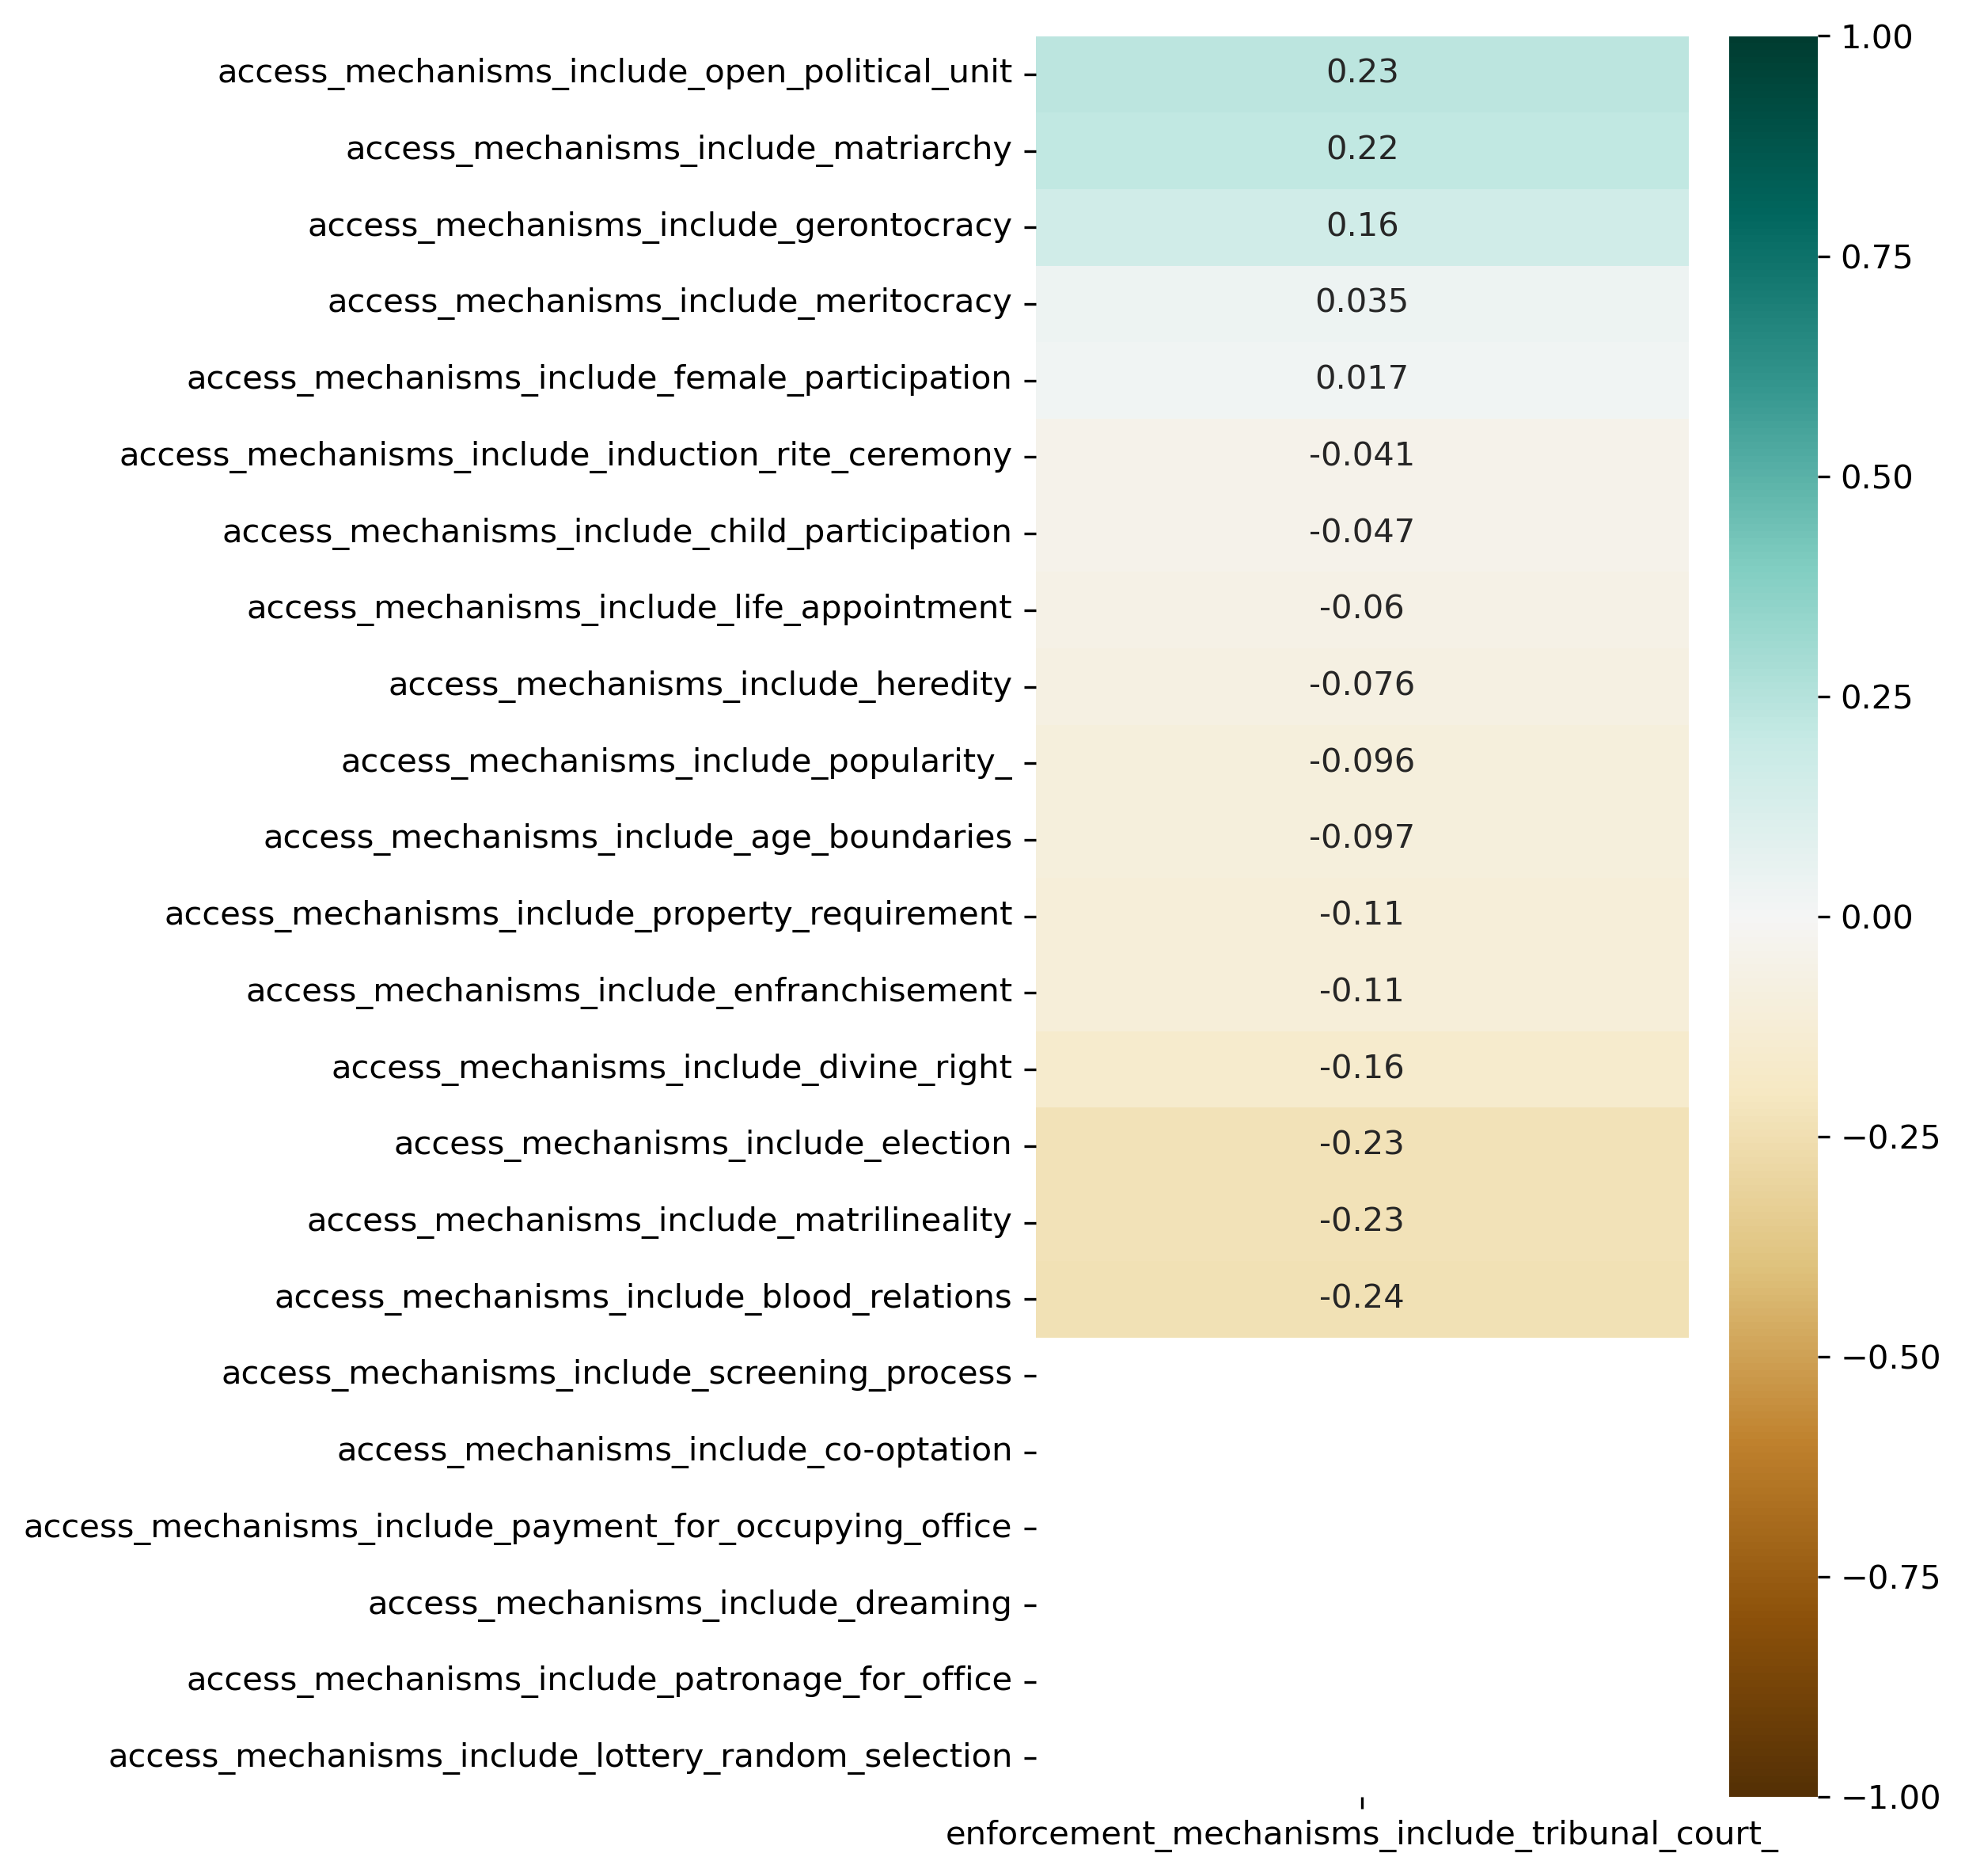

In [31]:
plt.figure(figsize=(8,8))
sns.heatmap(
    access_courts_corr.sort_values(by=courts, ascending=False), 
    annot=True,
    cmap='BrBG',
    vmin=-1,
    vmax=1
)

plt.tight_layout()
plt.savefig(fig_dir + 'access_courts_corr.png')
plt.show()

### Decision Making

In [32]:
dm_courts_corr = courts_corr[courts_corr.index.str.startswith('decision_making')]

In [33]:
dm_courts_corr

,enforcement_mechanisms_include_tribunal_court_
decision_making_mechanisms_include_representation,0.292995
decision_making_mechanisms_include_temporary_position_of_power_term_limits,-0.021999
decision_making_mechanisms_include_remunerated_position,-0.111504
decision_making_mechanisms_include_majority_voting,NaN
decision_making_mechanisms_include_plurality_voting,-0.111504
decision_making_mechanisms_include_assembly_local,0.151908
decision_making_mechanisms_include_petition,NaN
decision_making_mechanisms_include_secret_ballot,NaN
decision_making_mechanisms_include_coalition,NaN
decision_making_mechanisms_include_checks_and_balances,0.088294


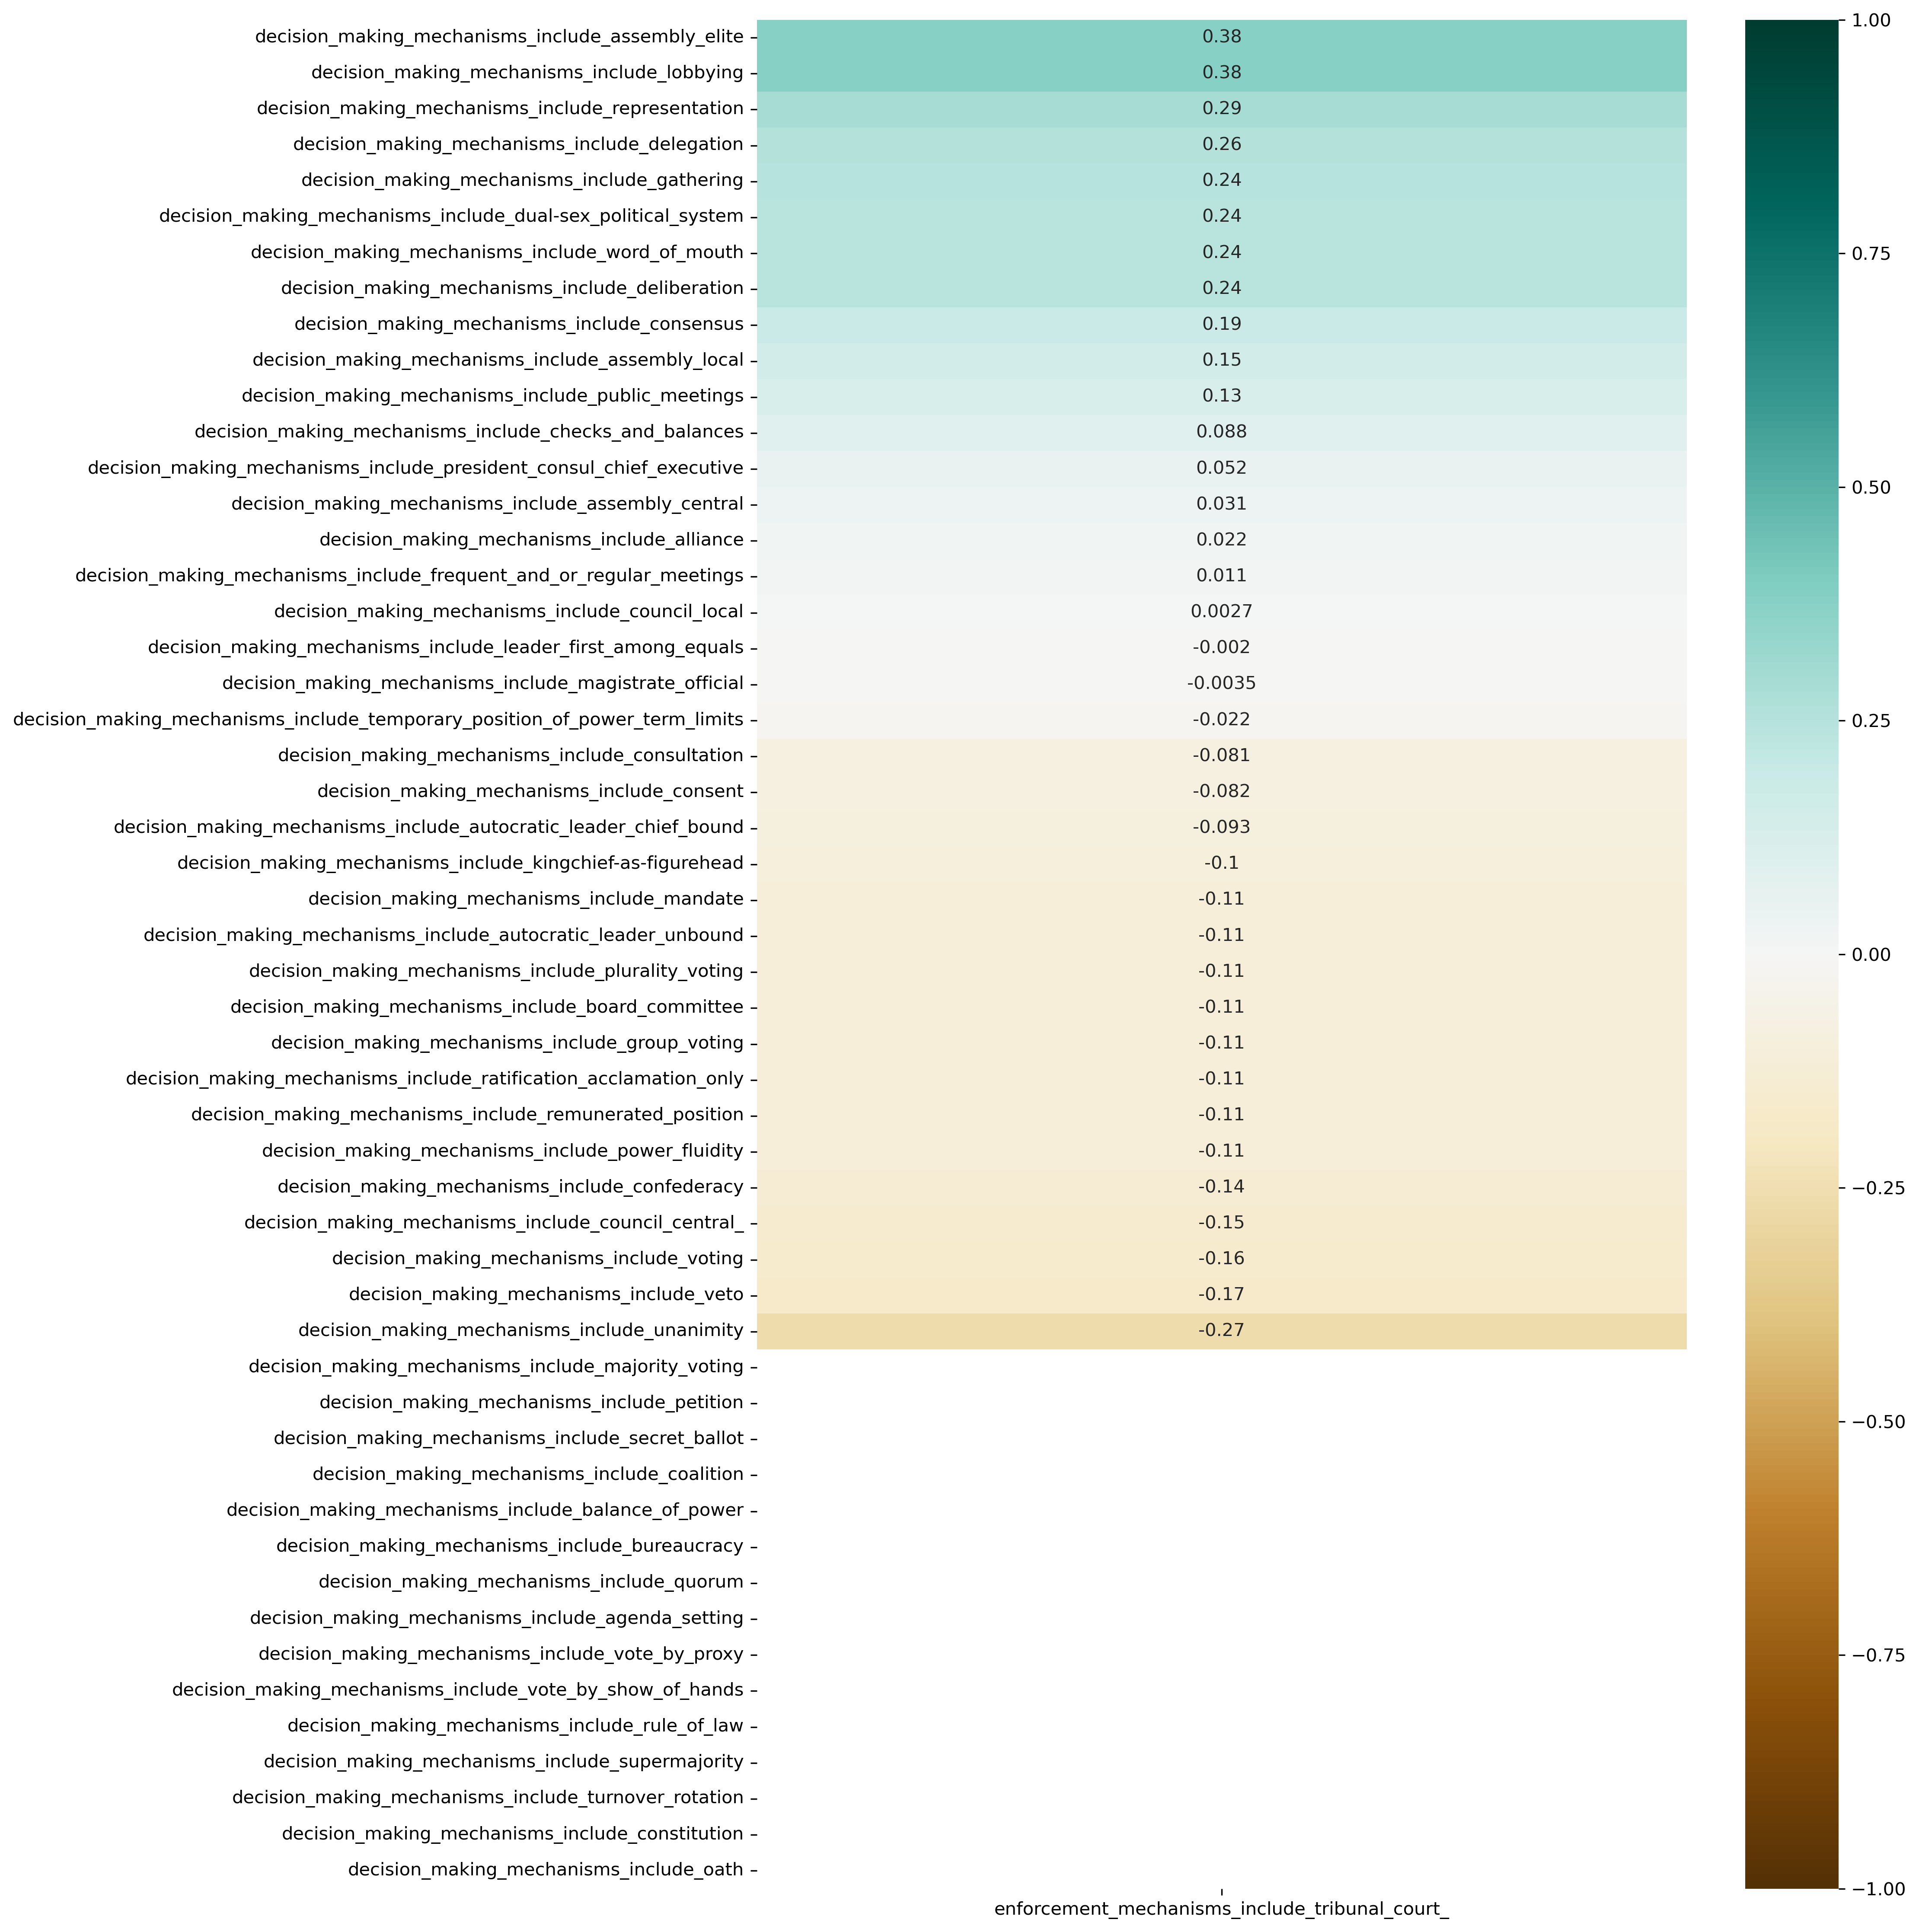

In [34]:
plt.figure(figsize=(15,15))
sns.heatmap(
    dm_courts_corr.sort_values(by=courts, ascending=False), 
    annot=True,
    cmap='BrBG',
    vmin=-1,
    vmax=1
)

plt.tight_layout()
plt.savefig(fig_dir + 'dm_courts_corr.png')
plt.show()

### Enforcement

In [35]:
enforcement_courts_corr = courts_corr[courts_corr.index.str.startswith('enforcement')]

In [36]:
enforcement_courts_corr

,enforcement_mechanisms_include_tribunal_court_
enforcement_mechanisms_include_paying_damages_compensation,NaN
enforcement_mechanisms_include_forced_labour,-0.111504
enforcement_mechanisms_include_graduated_sanctions,0.247580
enforcement_mechanisms_include_monitoring,NaN
enforcement_mechanisms_include_exit,0.070884
enforcement_mechanisms_include_self-help,0.068961
enforcement_mechanisms_include_civil_disobedience,-0.111504
enforcement_mechanisms_include_criticism_mocking_joking,0.075771
enforcement_mechanisms_include_appeal,NaN
enforcement_mechanisms_include_litigation,0.247581


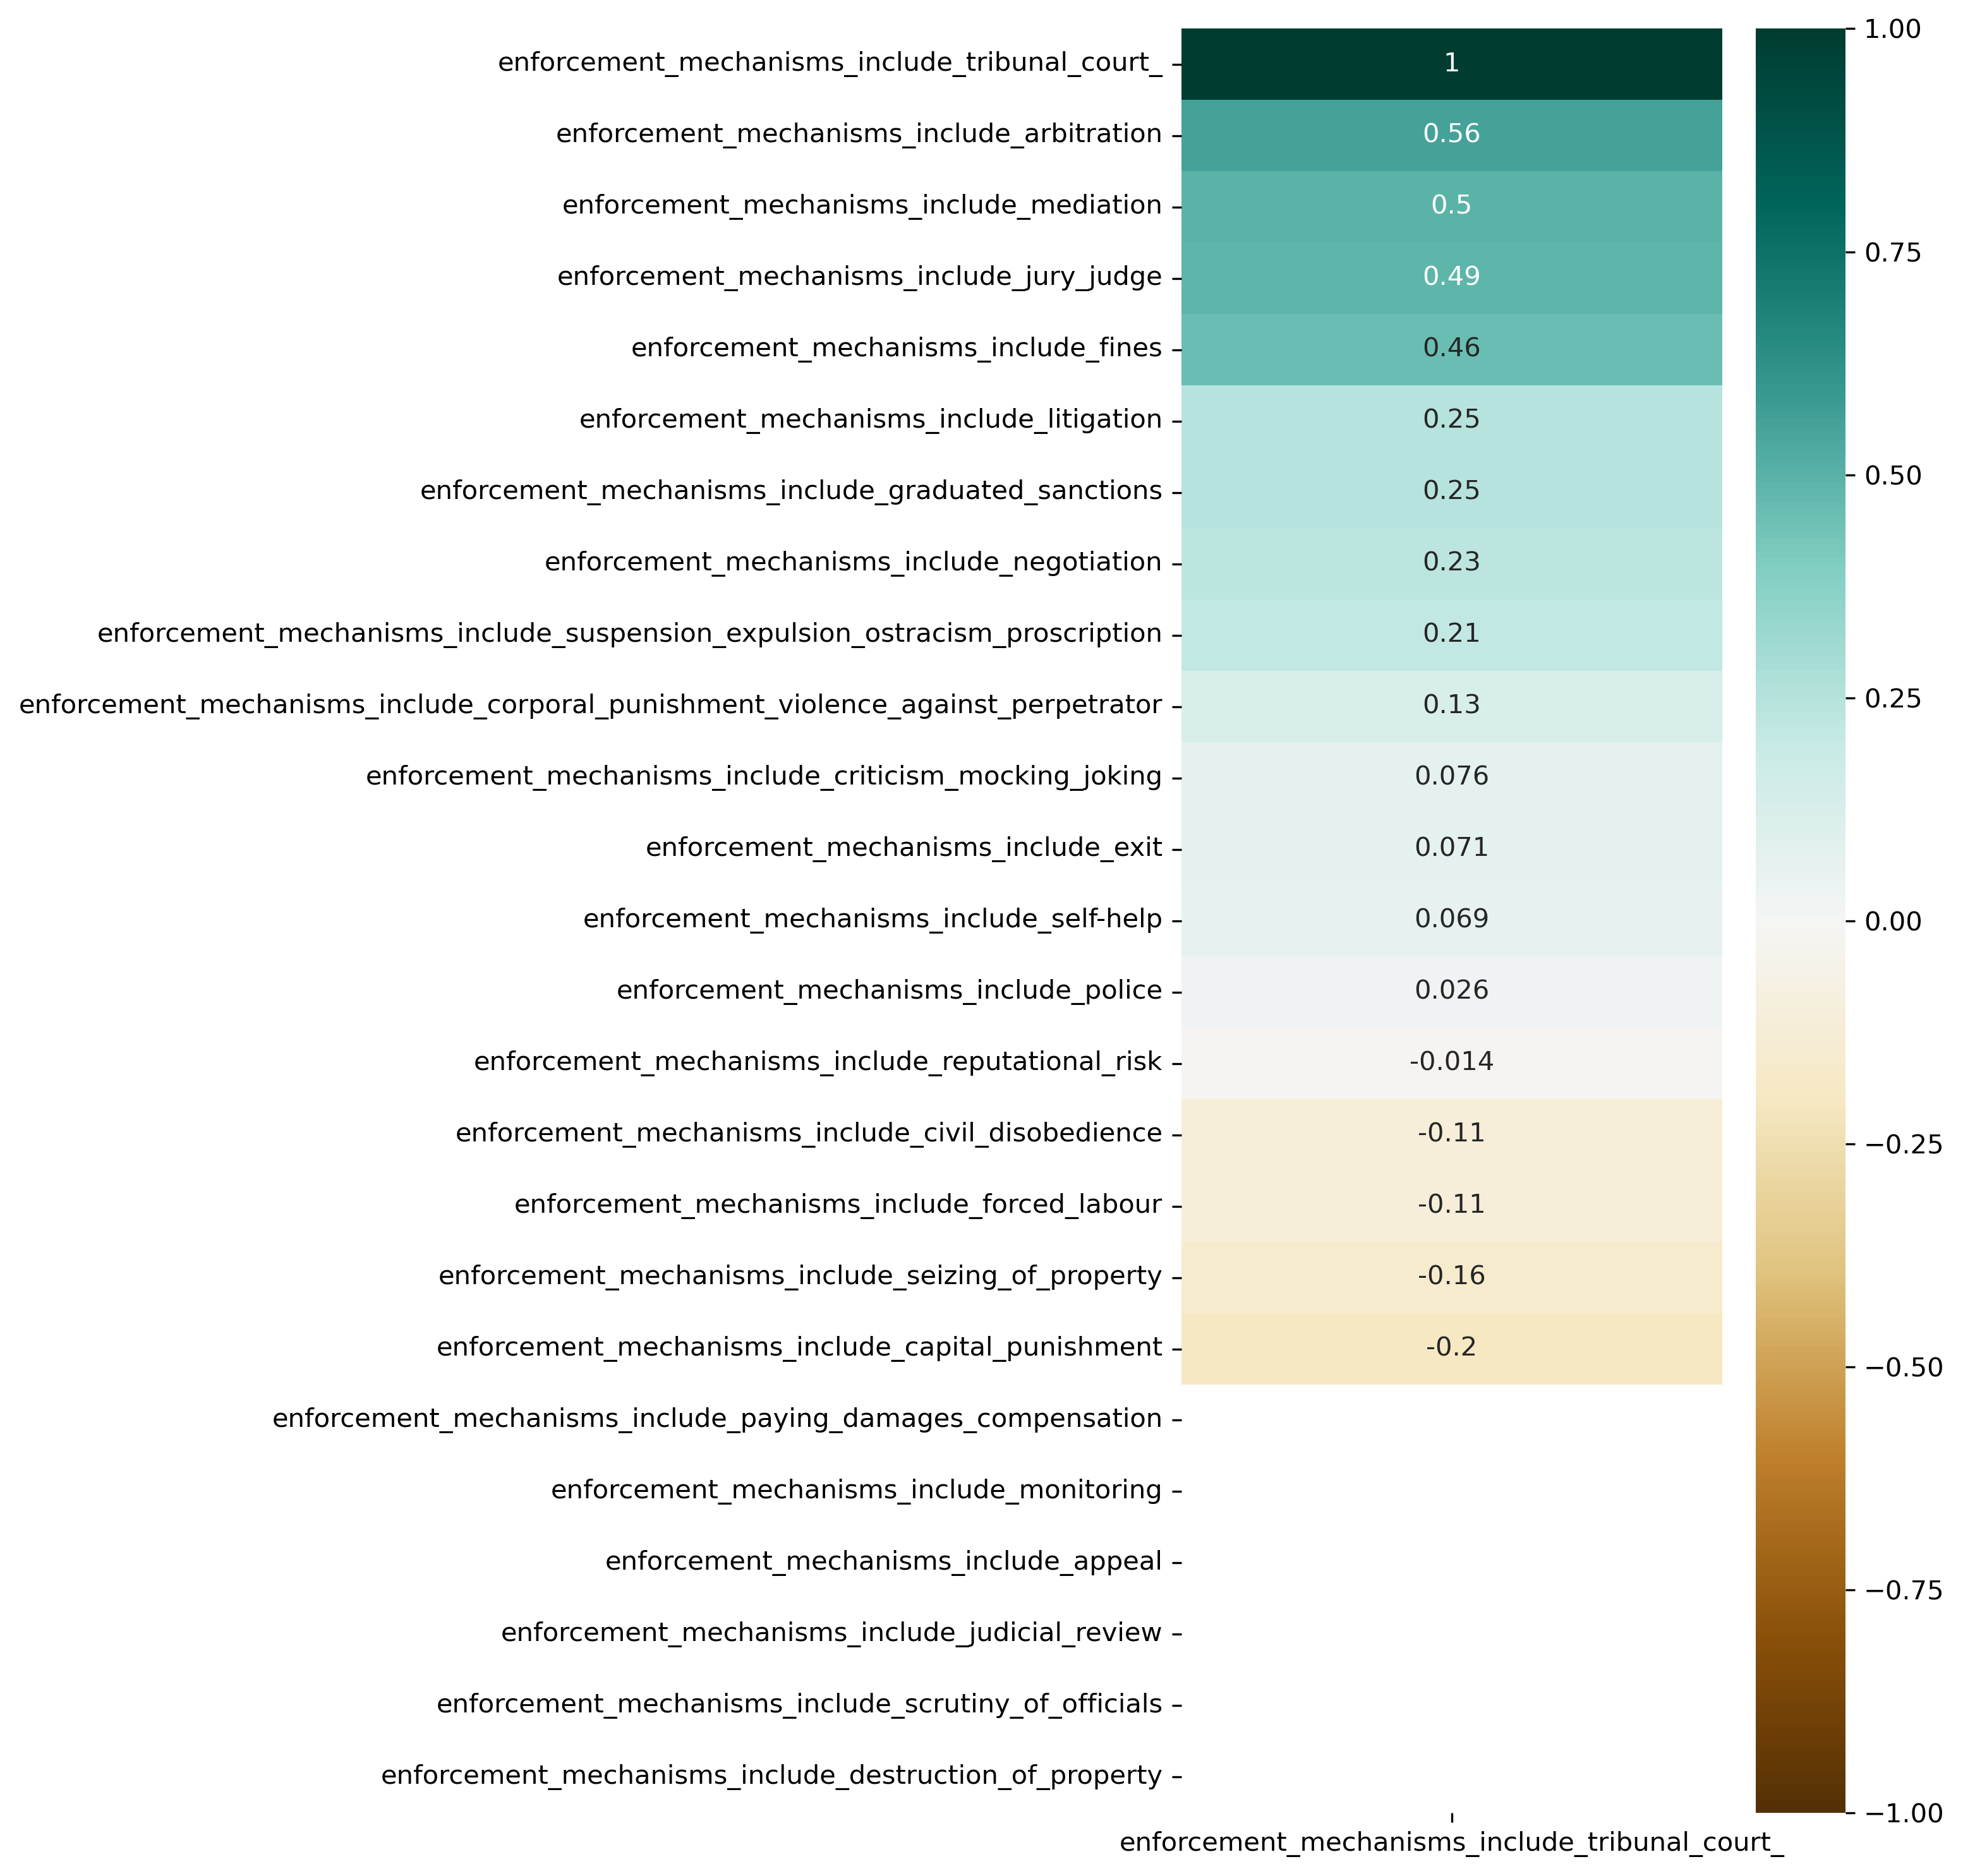

In [37]:
plt.figure(figsize=(10,10))
sns.heatmap(
    enforcement_courts_corr.sort_values(by=courts, ascending=False), 
    annot=True,
    cmap='BrBG',
    vmin=-1,
    vmax=1
)

plt.tight_layout()
plt.savefig(fig_dir + 'enforcement_courts_corr.png')
plt.show()

## Courts Analysis: Size

In [38]:
size_cols = [col for col in col_list if col.startswith('Size:')]
size_cols

['Size: 100 - 1,000',
 'Size: 1,001 - 10,000',
 'Size: 10,001 - 100,000',
 'Size: 100,001 - 1,000,000',
 'Size: 1,000,001 - 10,000,000',
 'Size: 10,000,000+',
 'Size: Unknown']

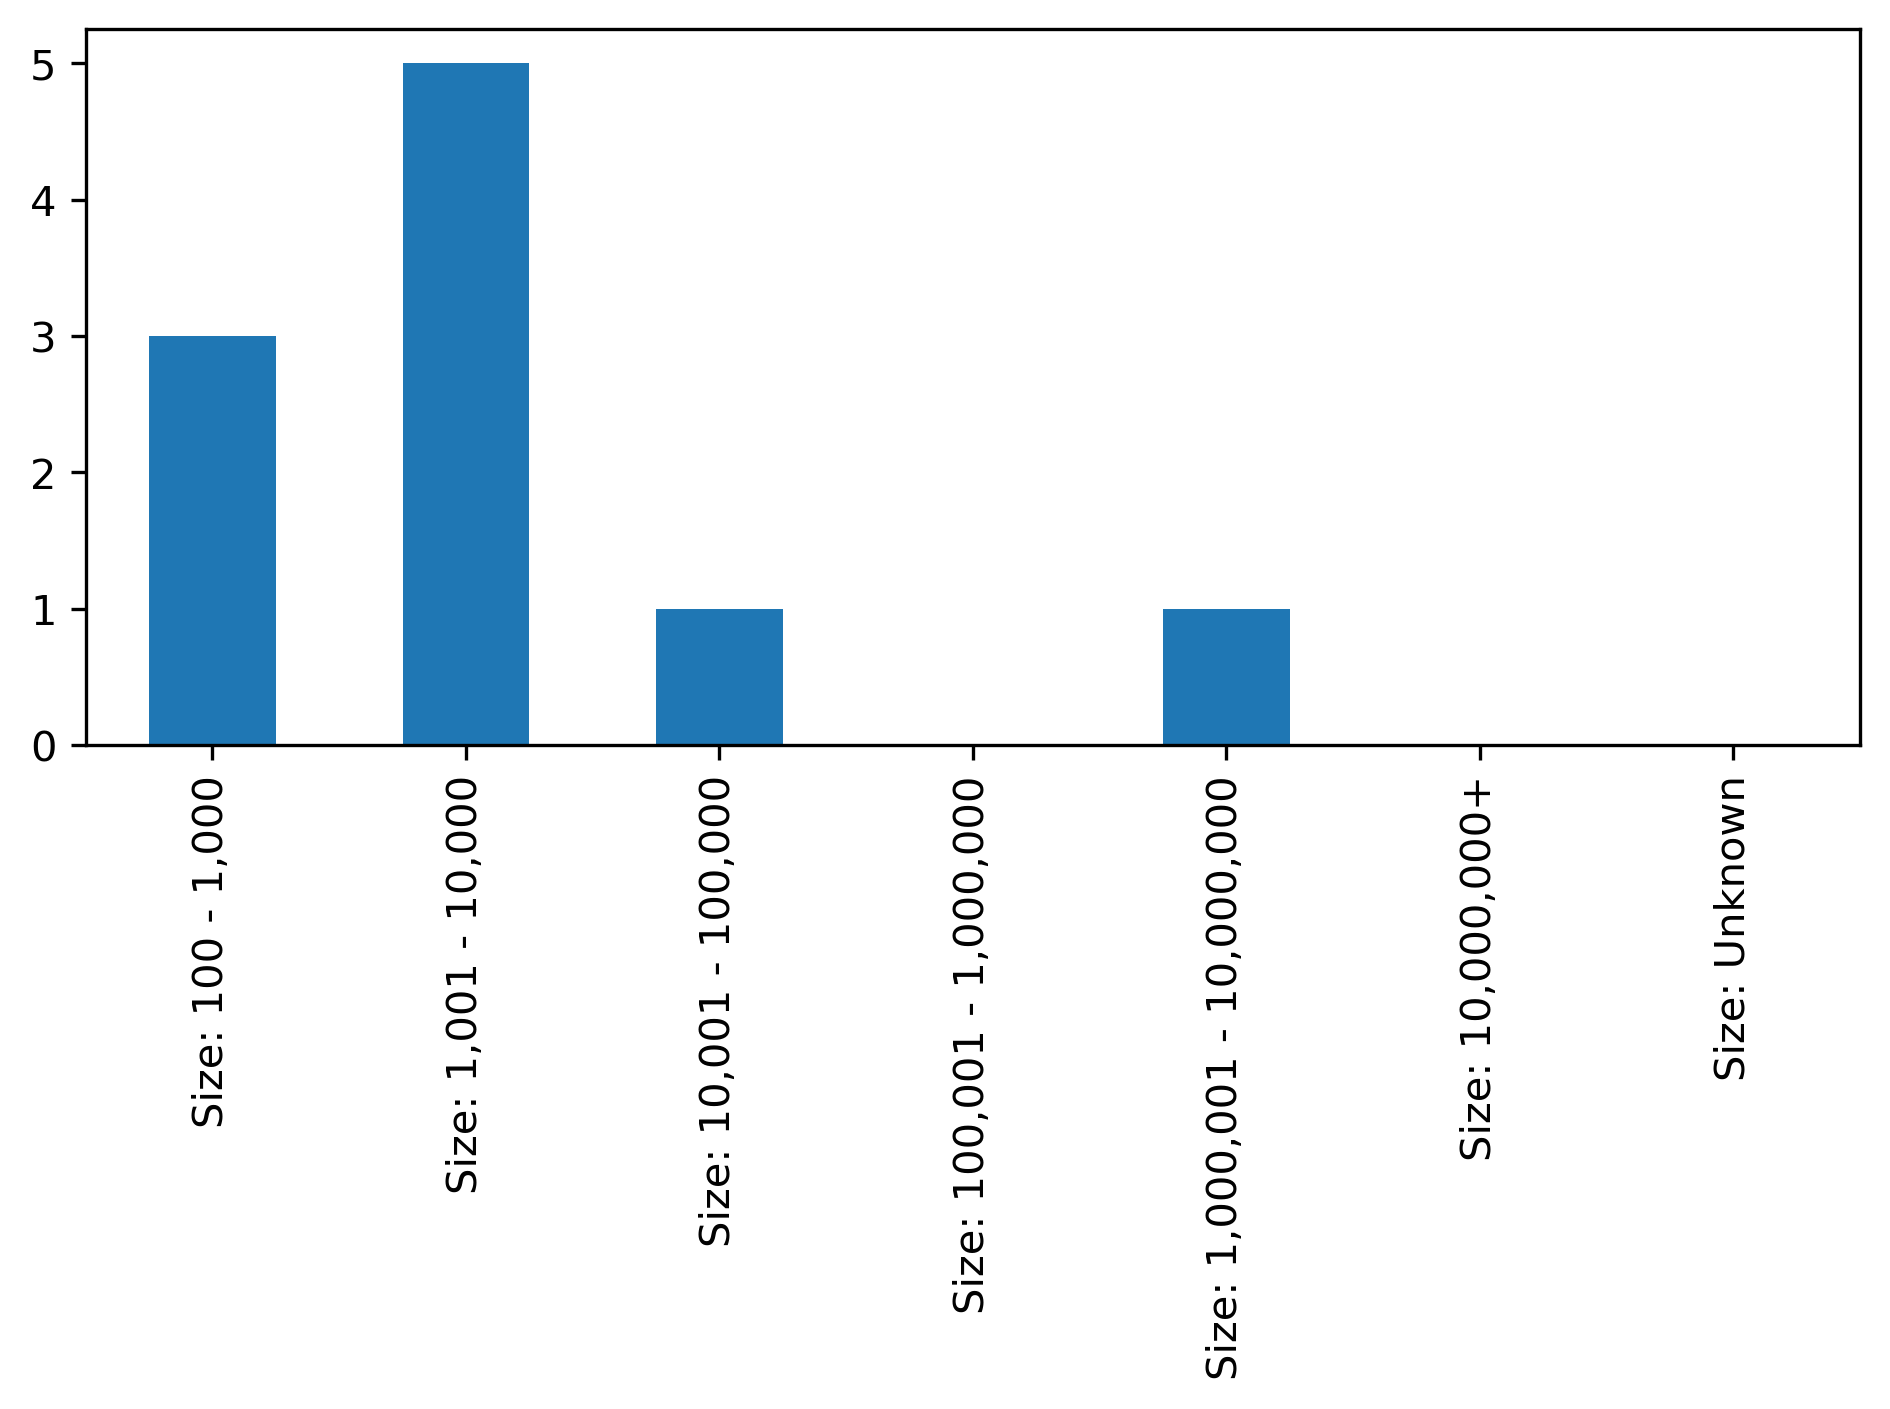

In [39]:
# Size histogram
courts_df[size_cols].sum().plot(kind='bar')

plt.tight_layout()
plt.savefig(fig_dir + 'courts_size_histogram.png')
plt.show()

In [40]:
size_courts_corr = courts_corr[courts_corr.index.str.startswith('Size:')]

In [41]:
size_courts_corr

,enforcement_mechanisms_include_tribunal_court_
"Size: 100 - 1,000",0.336768
"Size: 1,001 - 10,000",0.048611
"Size: 10,001 - 100,000",-0.229525
"Size: 100,001 - 1,000,000",-0.160090
"Size: 1,000,001 - 10,000,000",0.025910
"Size: 10,000,000+",NaN
Size: Unknown,-0.160059


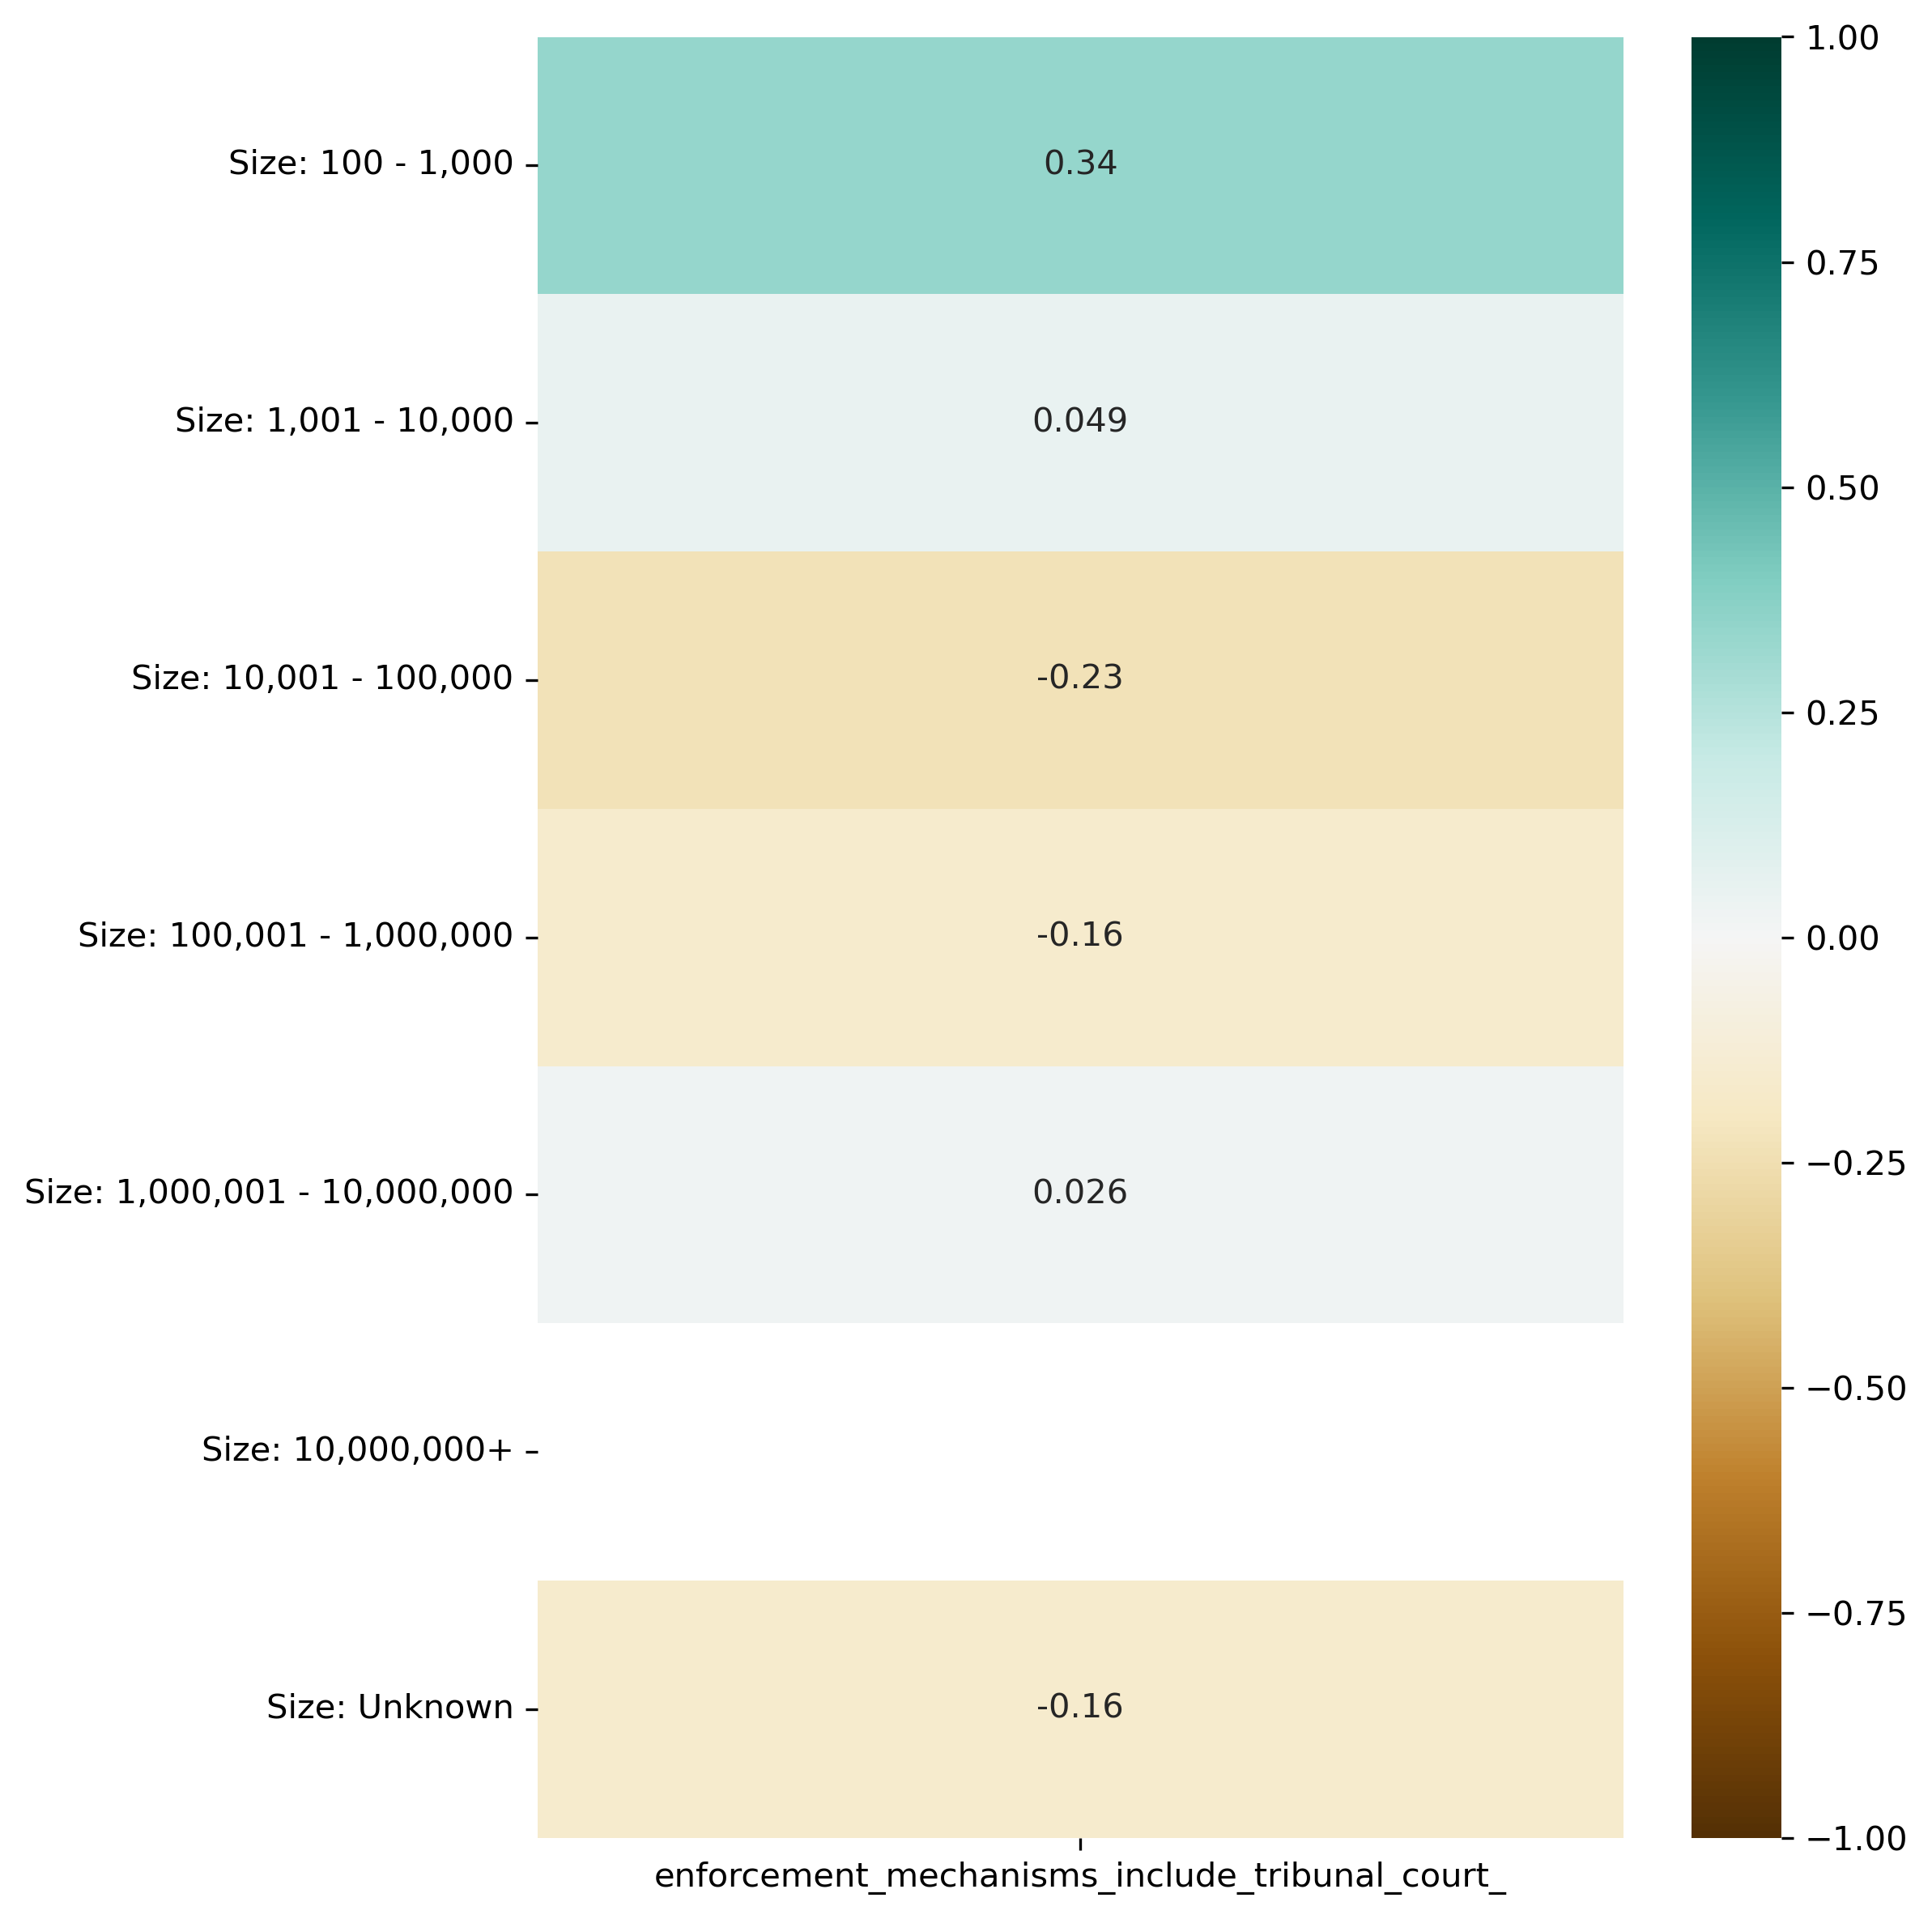

In [42]:
plt.figure(figsize=(8,8))
sns.heatmap(
    size_courts_corr, 
    annot=True,
    cmap='BrBG',
    vmin=-1,
    vmax=1
)

plt.tight_layout()
plt.savefig(fig_dir + 'courts_size_corr.png')
plt.show()

## Councils Analysis: Region

In [43]:
region_cols = [col for col in col_list if col.startswith('Region:')]
region_cols

['Region: Africa',
 'Region: Europe',
 'Region: Asia',
 'Region: Middle East',
 'Region: North America',
 'Region: Central America',
 'Region: South America',
 'Region: Oceania']

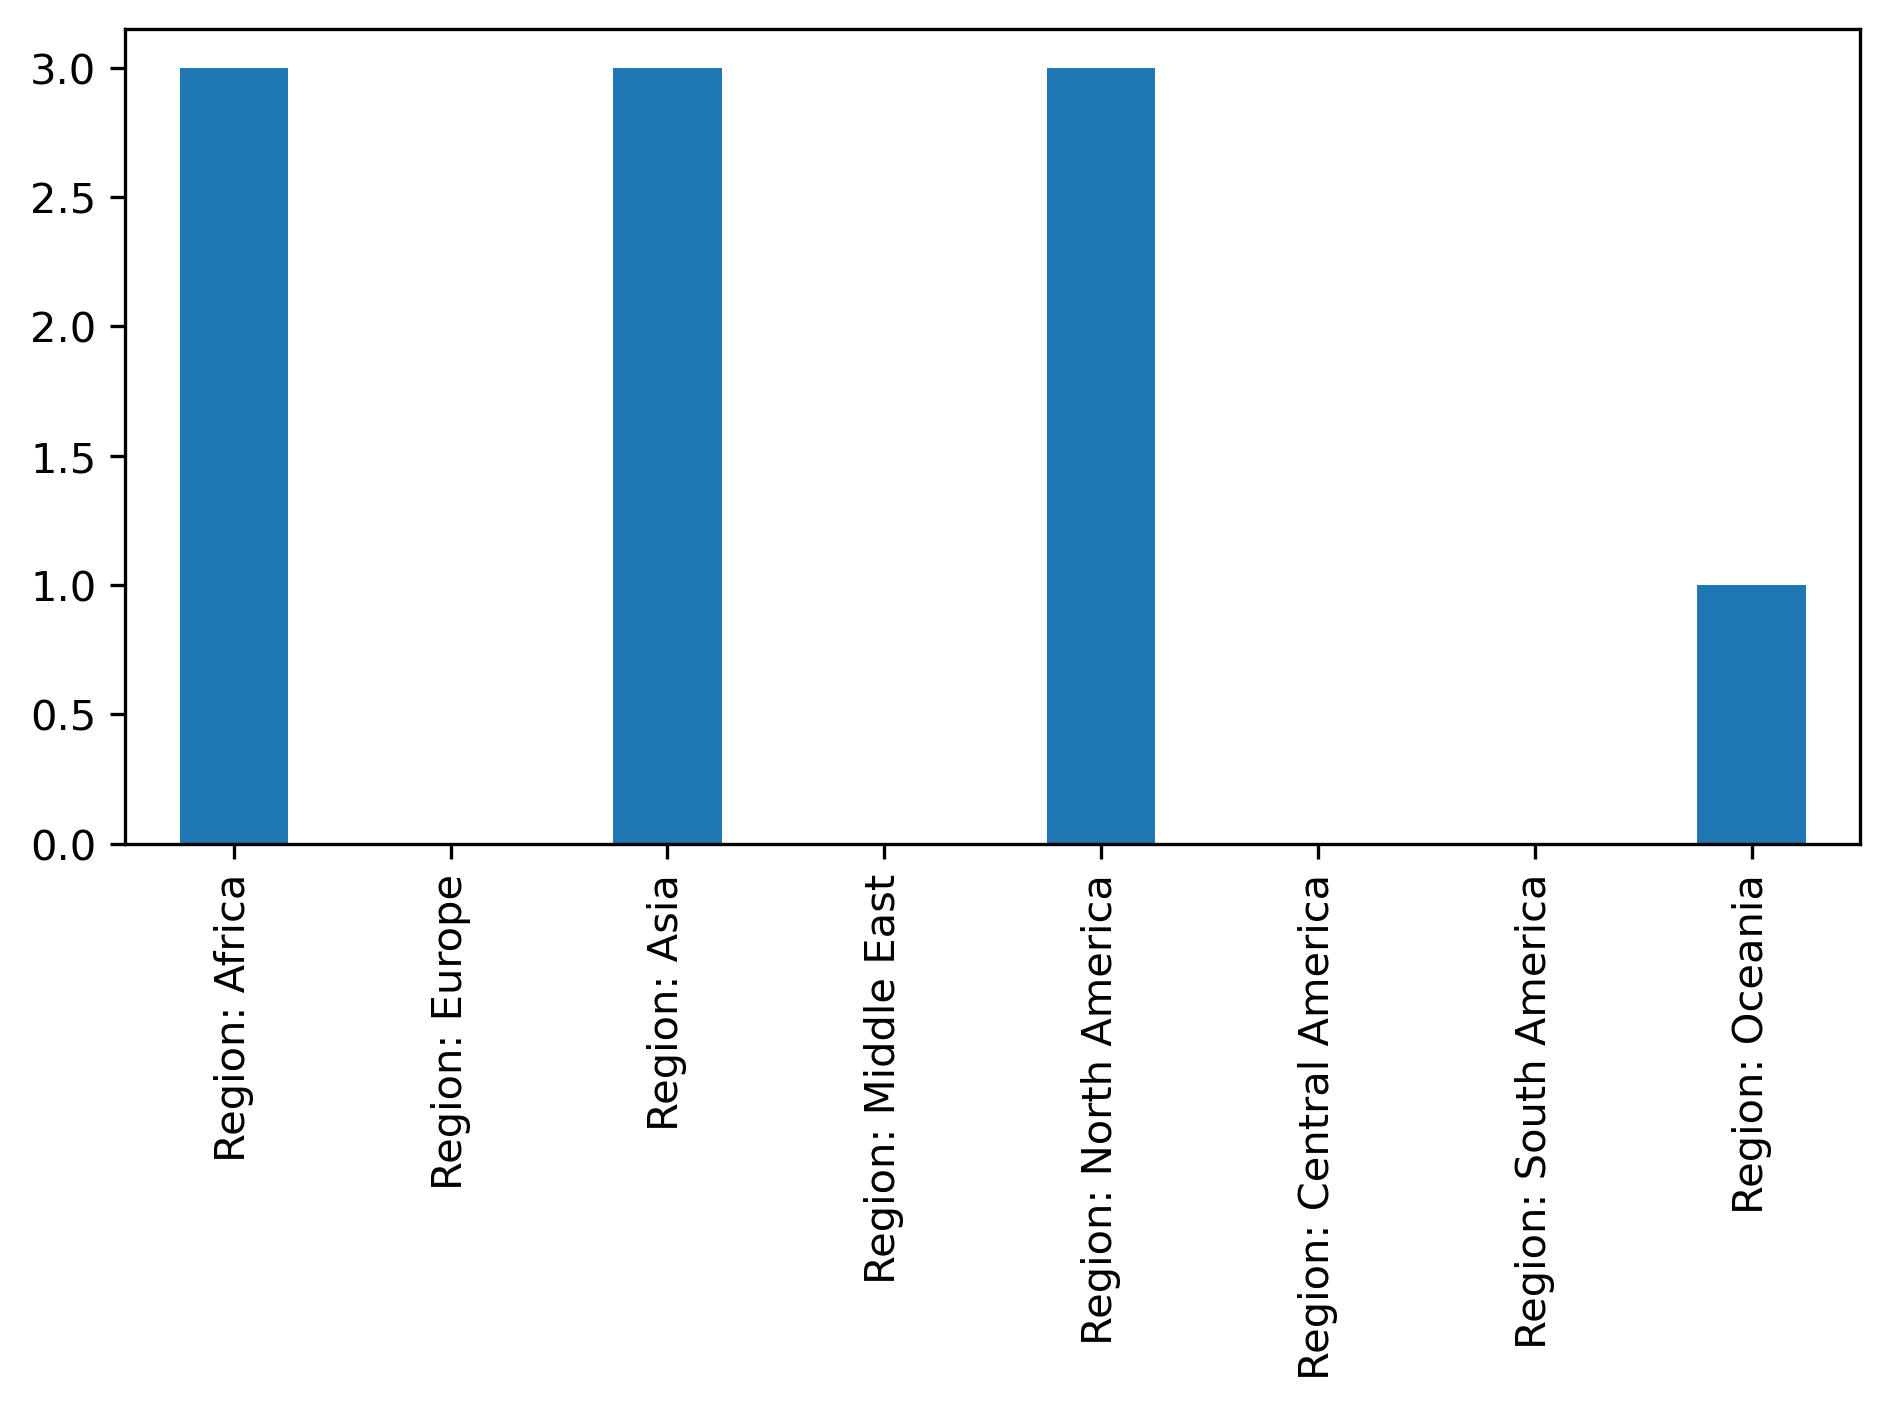

In [44]:
# Region histogram
courts_df[region_cols].sum().plot(kind='bar')

plt.tight_layout()
plt.savefig(fig_dir + 'courts_region_histogram.png')
plt.show()

In [45]:
region_courts_corr = courts_corr[courts_corr.index.str.startswith('Region:')]

In [46]:
region_courts_corr

,enforcement_mechanisms_include_tribunal_court_
Region: Africa,0.178457
Region: Europe,-0.111504
Region: Asia,0.466926
Region: Middle East,-0.111504
Region: North America,-0.092263
Region: Central America,-0.111504
Region: South America,-0.232877
Region: Oceania,-0.069914


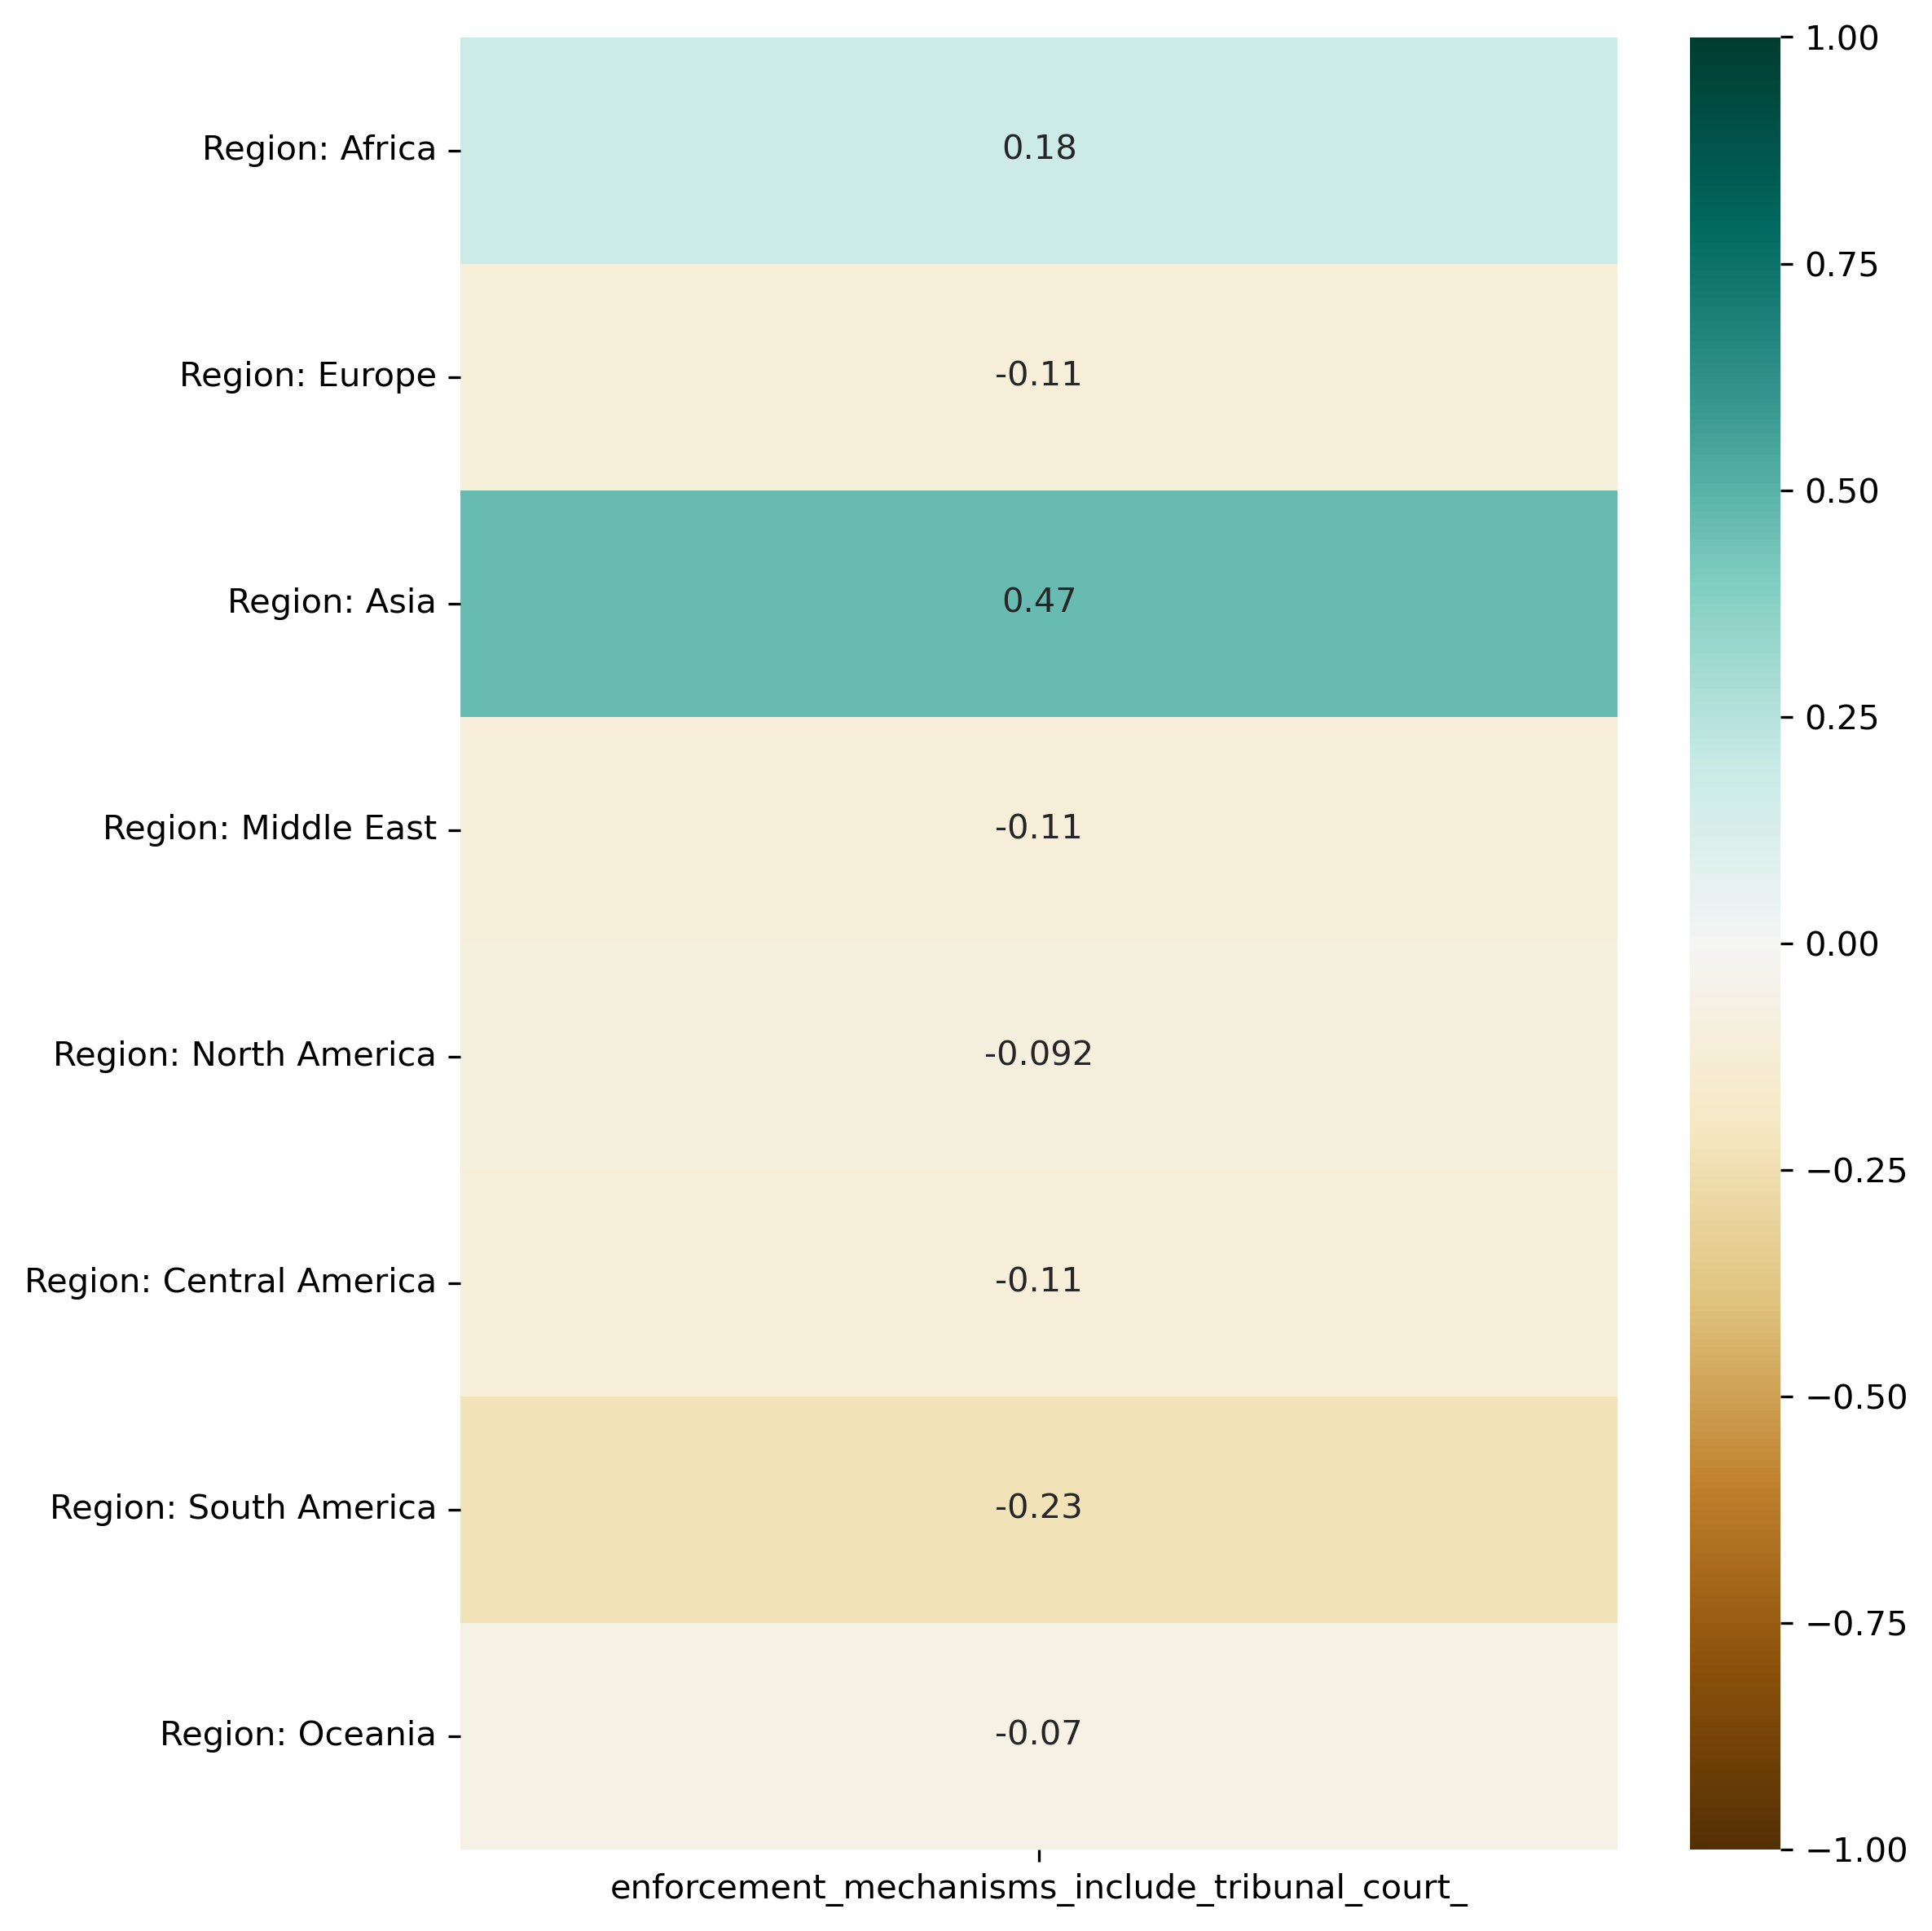

In [47]:
plt.figure(figsize=(8,8))
sns.heatmap(
    region_courts_corr, 
    annot=True,
    cmap='BrBG',
    vmin=-1,
    vmax=1
)

plt.tight_layout()
plt.savefig(fig_dir + 'courts_region_corr.png')
plt.show()

### Mapping council regions

In [48]:
worldmap = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

worldmap.head()

/var/folders/v7/8x_7ty4j3m76hgg7tncks_kc0000gn/T/ipykernel_2854/1532259957.py:1: FutureWarning:

The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.



,pop_est,continent,name,iso_a3,gdp_md_est,geometry
0,889953.0,Oceania,Fiji,FJI,5496,"MULTIPOLYGON (((180.00000 -16.06713, 180.00000..."
1,58005463.0,Africa,Tanzania,TZA,63177,"POLYGON ((33.90371 -0.95000, 34.07262 -1.05982..."
2,603253.0,Africa,W. Sahara,ESH,907,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,37589262.0,North America,Canada,CAN,1736425,"MULTIPOLYGON (((-122.84000 49.00000, -122.9742..."
4,328239523.0,North America,United States of America,USA,21433226,"MULTIPOLYGON (((-122.84000 49.00000, -120.0000..."


In [49]:
central_america_countries = [
    'Belize',
    'Costa Rica',
    'El Salvador',
    'Guatemala',
    'Honduras',
    'Nicaragua',
    'Panama'
]

middle_east_countries = [
    'Cyprus',
    'Egypt',
    'Iran',
    'Iraq',
    'Israel',
    'Jordan',
    'Kuwait',
    'Lebanon',
    'Oman',
    'Palestine',
    'Qatar',
    'Saudi Arabia',
    'Syria',
    'Turkey',
    'United Arab Emirates',
    'Yemen'
]

# Add region for Central America
worldmap.loc[(worldmap['name'].isin(central_america_countries)), 'continent'] = 'Central America'

# Add region for Middle East
worldmap.loc[(worldmap['name'].isin(middle_east_countries)), 'continent'] = 'Middle East'

worldmap['continent'].value_counts()

continent
Africa                     50
Europe                     39
Asia                       32
Middle East                16
South America              13
North America              11
Oceania                     7
Central America             7
Seven seas (open ocean)     1
Antarctica                  1
Name: count, dtype: int64

In [50]:
region_map = gpd.GeoDataFrame(columns=['Region', 'geometry'])
regions_list = list(gov_df['Region'].unique())

In [51]:
region_map['Region'] = regions_list

region_map['geometry'].loc[region_map['Region'] == 'Africa'] = worldmap.loc[(worldmap['continent'] == 'Africa')].unary_union
region_map['geometry'].loc[region_map['Region'] == 'Europe'] = worldmap.loc[(worldmap['continent'] == 'Europe')].unary_union
region_map['geometry'].loc[region_map['Region'] == 'Asia'] = worldmap.loc[(worldmap['continent'] == 'Asia')].unary_union
region_map['geometry'].loc[region_map['Region'] == 'Middle East'] = worldmap.loc[(worldmap['continent'] == 'Middle East')].unary_union
region_map['geometry'].loc[region_map['Region'] == 'North America'] = worldmap.loc[(worldmap['continent'] == 'North America')].unary_union
region_map['geometry'].loc[region_map['Region'] == 'Central America'] = worldmap.loc[(worldmap['continent'] == 'Central America')].unary_union
region_map['geometry'].loc[region_map['Region'] == 'South America'] = worldmap.loc[(worldmap['continent'] == 'South America')].unary_union
region_map['geometry'].loc[region_map['Region'] == 'Oceania'] = worldmap.loc[(worldmap['continent'] == 'Oceania')].unary_union

region_map

/var/folders/v7/8x_7ty4j3m76hgg7tncks_kc0000gn/T/ipykernel_2854/454843215.py:3: FutureWarning:

ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


/var/folders/v7/8x_7ty4j3m76hgg7tncks_kc0000gn/T/ipykernel_2854/454843215.py:4: FutureWarning:

ChainedAssignmentEr

,Region,geometry
0,Middle East,"MULTIPOLYGON (((25.000 25.682, 25.000 29.239, ..."
1,Africa,"MULTIPOLYGON (((-11.439 6.786, -11.708 6.860, ..."
2,South America,"MULTIPOLYGON (((-68.640 -55.580, -69.232 -55.4..."
3,North America,"MULTIPOLYGON (((-155.222 19.240, -155.542 19.0..."
4,Europe,"MULTIPOLYGON (((-53.555 2.335, -53.779 2.377, ..."
5,Oceania,"MULTIPOLYGON (((147.914 -43.212, 147.565 -42.9..."
6,Asia,"MULTIPOLYGON (((105.857 -4.306, 105.818 -5.852..."
7,Central America,"POLYGON ((-77.243 7.935, -77.431 7.638, -77.75..."


#### All Councils

In [52]:
courts_region_map = region_map

In [53]:
courts_region_counts = courts_df['Region'].value_counts().rename_axis('Region').reset_index(name='Count')

In [54]:
courts_region_counts

,Region,Count
0,Africa,3
1,Asia,3
2,North America,3
3,Oceania,1


In [55]:
# Custom: Add empty regions
missing_regions_df = pd.DataFrame([['South America', 0],['North America', 0]], columns=['Region', 'Count'])
missing_regions_df

,Region,Count
0,South America,0
1,North America,0


In [56]:
# Custom: Add empty regions
courts_region_counts = pd.concat([courts_region_counts, missing_regions_df])
courts_region_counts

,Region,Count
0,Africa,3
1,Asia,3
2,North America,3
3,Oceania,1
0,South America,0
1,North America,0


In [57]:
all_merged_regions = pd.merge(courts_region_map, courts_region_counts, on='Region')

In [58]:
all_merged_regions

,Region,geometry,Count
0,Africa,"MULTIPOLYGON (((-11.43878 6.78592, -11.70819 6...",3
1,South America,"MULTIPOLYGON (((-68.63999 -55.58002, -69.23210...",0
2,North America,"MULTIPOLYGON (((-155.22217 19.23972, -155.5421...",3
3,North America,"MULTIPOLYGON (((-155.22217 19.23972, -155.5421...",0
4,Oceania,"MULTIPOLYGON (((147.91405 -43.21152, 147.56456...",1
5,Asia,"MULTIPOLYGON (((105.85745 -4.30552, 105.81766 ...",3


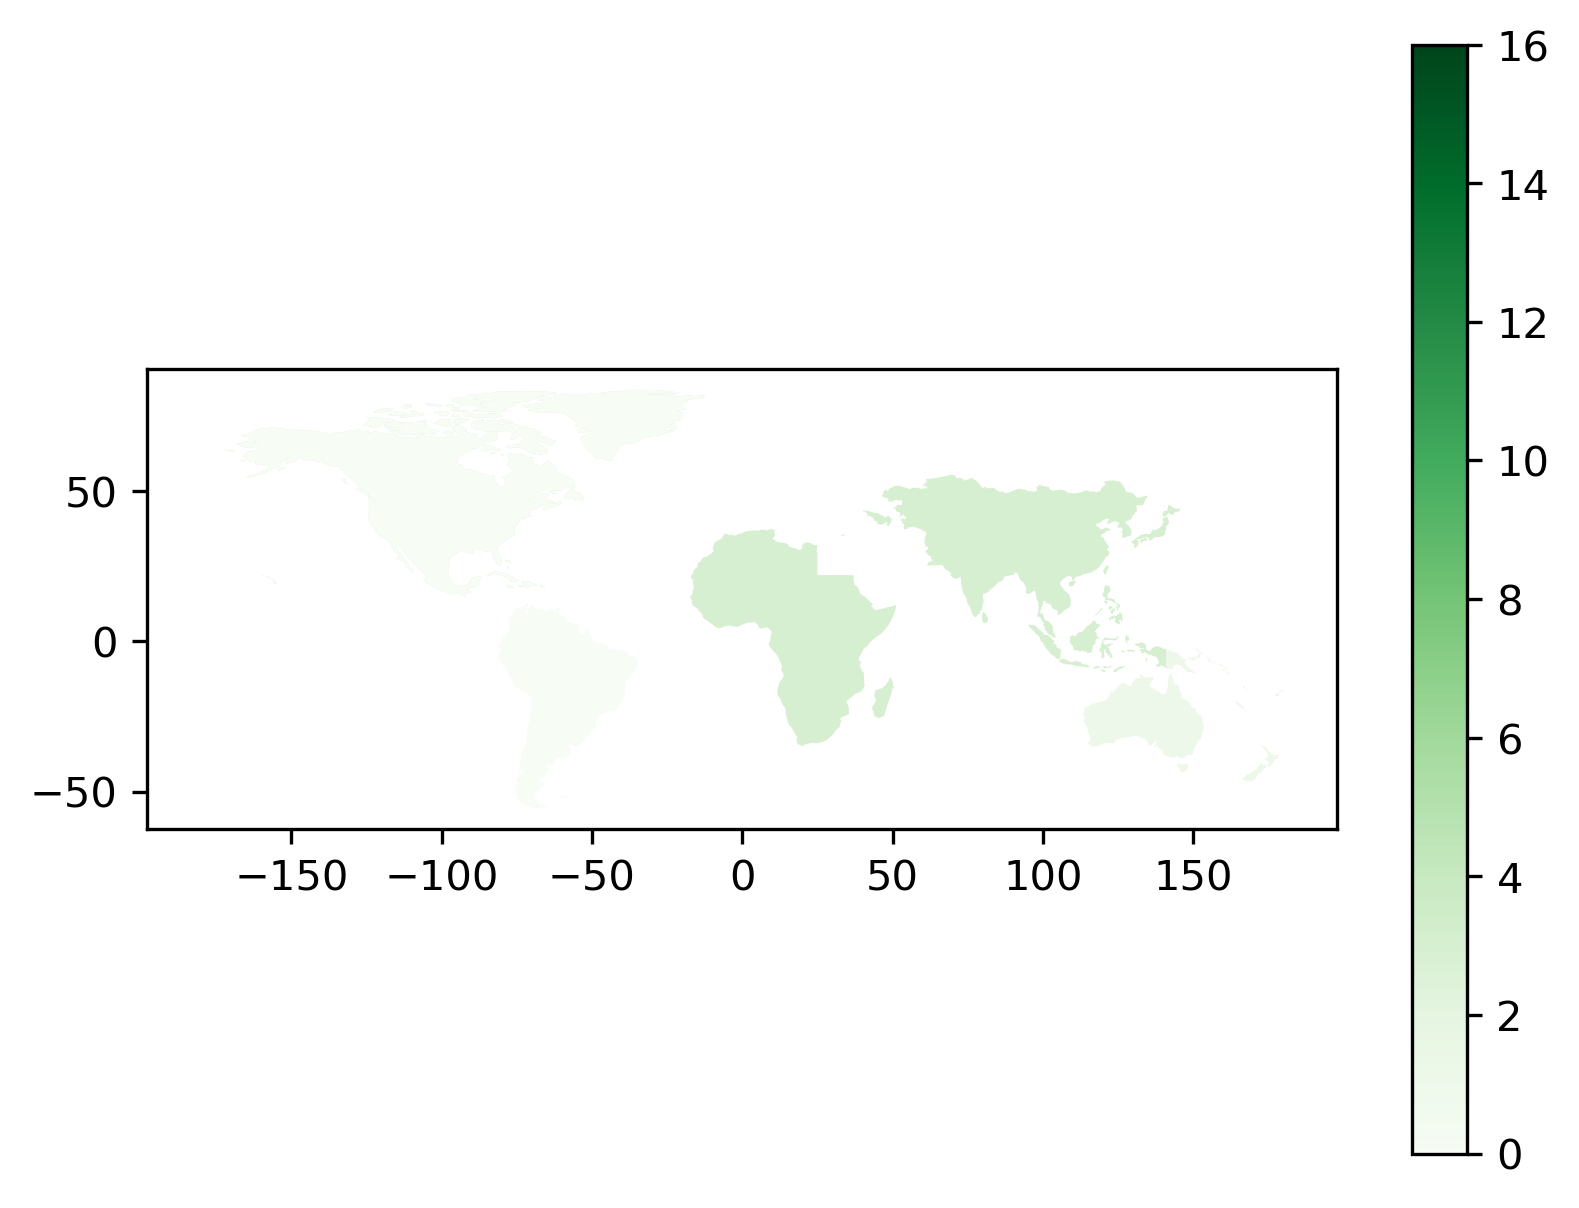

In [59]:
all_merged_regions.plot(
    column='Count', 
    legend=True,
    cmap='Greens',
    vmin=0,
    vmax=16
)

plt.savefig(fig_dir + 'map_courts_all.png')
plt.show()

## Courts Analysis: Timeline 

In [60]:
courts_dates_df = courts_df[['Time span: Start', 'Time span: Duration', 'Name'] + court_col]

In [61]:
courts_dates_df

,Time span: Start,Time span: Duration,Name,enforcement_mechanisms_include_tribunal_court_
27,900,660,Igbo People,1
36,1900,123,Kung San (Ju/hoansi),1
72,1400,500,Gilbertese,1
73,1800,100,Toda,1
74,1600,350,Nicobarese,1
75,1600,200,Gilyak (Nivkh),1
76,1800,100,Nama,1
81,1800,100,Ingalik [Deg Xit'an],1
82,1700,200,Kutenai,1
83,1500,500,Micmac [Mi'kmaq],1


In [62]:
courts_dates_tuples = [tuple(x) for x in courts_dates_df.to_numpy()]
courts_dates_tuples

[(900, 660, 'Igbo People', 1),
 (1900, 123, 'Kung San (Ju/hoansi)', 1),
 (1400, 500, 'Gilbertese', 1),
 (1800, 100, 'Toda', 1),
 (1600, 350, 'Nicobarese', 1),
 (1600, 200, 'Gilyak (Nivkh)', 1),
 (1800, 100, 'Nama', 1),
 (1800, 100, "Ingalik [Deg Xit'an]", 1),
 (1700, 200, 'Kutenai', 1),
 (1500, 500, "Micmac [Mi'kmaq]", 1)]

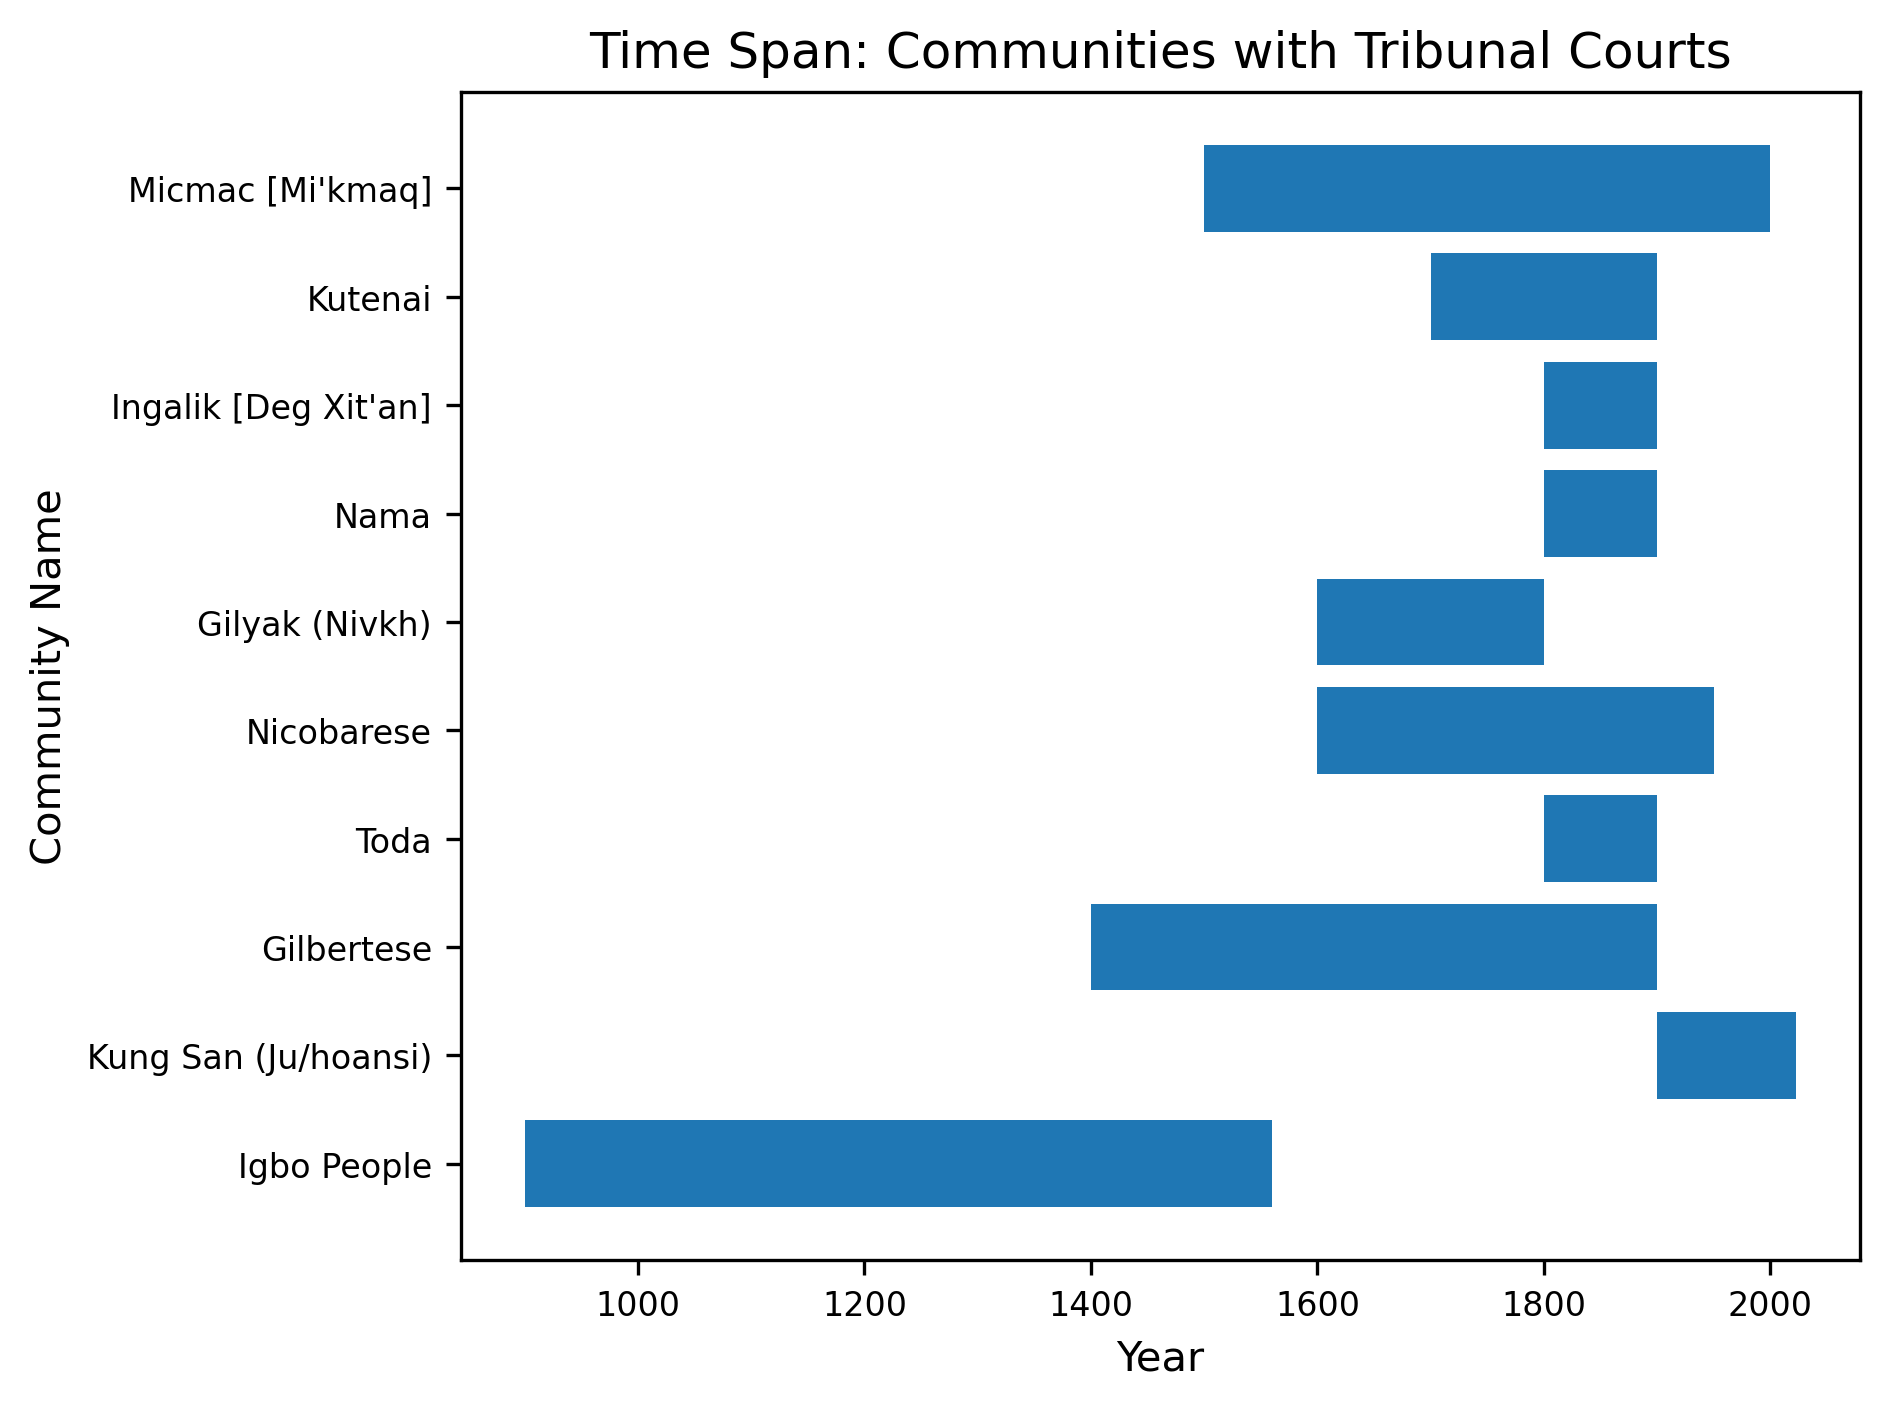

In [63]:
# create figure and plot
fig, ax = plt.subplots()
labels = []
for i, (
    start, 
    duration, 
    label, 
    has_courts,
) in enumerate(courts_dates_tuples):
    # bar_color = 'blue'
    
    labels.append(label)
    ax.broken_barh(
        [(start, duration)], 
        (i-0.4,0.8),
        # color=bar_color
    )
    
# set yticks at the middle of the bars
ax.set_yticks(range(len(courts_dates_tuples)))
ax.set_yticklabels(labels)
ax.tick_params(axis='both', which='major', labelsize=8)

ax.set_xlabel('Year')
ax.set_ylabel('Community Name')

plt.title('Time Span: Communities with Tribunal Courts')
# plt.figure(figsize=(80, 80))

plt.tight_layout()
plt.savefig(fig_dir + 'timeline_courts.png')
plt.show()